In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from pandas.tseries.offsets import BDay

DATA_DIR      = Path('data/raw')
PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

BUSINESS_CAL = pd.date_range('2010-01-01', '2025-12-31', freq=BDay())


In [2]:

import pandas as pd
from datetime import date
import requests
from fredapi import Fred


FRED_API_KEY = "d5ae41a9631b08bf79fbc8759f583803"  # Louis Fed key
EIA_API_KEY  = "dFfF9oSJ4RbP3desP1WuM8gbV7nmjf1vniEYrfKz"   #  EIA key
START_DATE   = "1992-01-01"                   
END_DATE     = date.today().strftime("%Y-%m-%d")
OUTPUT_FILE  = "lpg_dataset.csv"

def dedup(s):
    """Return Series/DataFrame with duplicate datetime index removed (keep last)."""
    return s[~s.index.duplicated(keep="last")]

# FRED price & driver series 
fred = Fred(api_key=FRED_API_KEY)

FRED_SERIES = {
    "lpg_price": "DPROPANEMBTX",   # Mont Belvieu Propane spot $/gal
    "brent":     "DCOILBRENTEU",   # Brent crude $/bbl
    "wti":       "DCOILWTICO",     # WTI crude $/bbl
    "natgas":    "DHHNGSP",        # Henry Hub $/MMBtu
}

fred_frames = []
for name, sid in FRED_SERIES.items():
    ser = fred.get_series(sid).loc[START_DATE:END_DATE]
    ser = ser.to_frame(name)
    fred_frames.append(ser)

data_fred = dedup(pd.concat(fred_frames, axis=1))

# EIA weekly product‑supplied (propane + propylene)

def fetch_eia_weekly_pp_demand(start=START_DATE, end=END_DATE):
    url = (
        "https://api.eia.gov/v2/petroleum/cons/wpsup/data/"
        "?frequency=weekly&data[0]=value"
        f"&start={start}&end={end}"
        "&sort[0][column]=period&sort[0][direction]=asc"
        f"&api_key={EIA_API_KEY}"
    )
    r = requests.get(url).json()
    if "response" not in r:
        raise ValueError(f"EIA API error → {r.get('error', r)}")
    df = (pd.DataFrame(r["response"]["data"])
            [["period", "value"]]
            .assign(period=lambda x: pd.to_datetime(x["period"]))
            .set_index("period")
            .rename(columns={"value": "us_propane_demand"}))
    return dedup(df)

weekly_demand = fetch_eia_weekly_pp_demand()



df = dedup(
    data_fred
    .join(weekly_demand)
    .sort_index()
)


df_daily = dedup(df).resample("D").ffill()


df.to_csv(OUTPUT_FILE.replace(".csv", "_nativefreq.csv"))
df_daily.to_csv(OUTPUT_FILE)

print("Saved native‑frequency data →", OUTPUT_FILE.replace('.csv', '_nativefreq.csv'))
print("Saved daily up‑sampled data →", OUTPUT_FILE)


✅  Saved native‑frequency data → lpg_dataset_nativefreq.csv
✅  Saved daily up‑sampled data → lpg_dataset.csv


Loaded 12242 rows × 5 columns

Missing values per column:
 lpg_price             696
brent                 357
wti                   489
natgas               2247
us_propane_demand    9101
dtype: int64


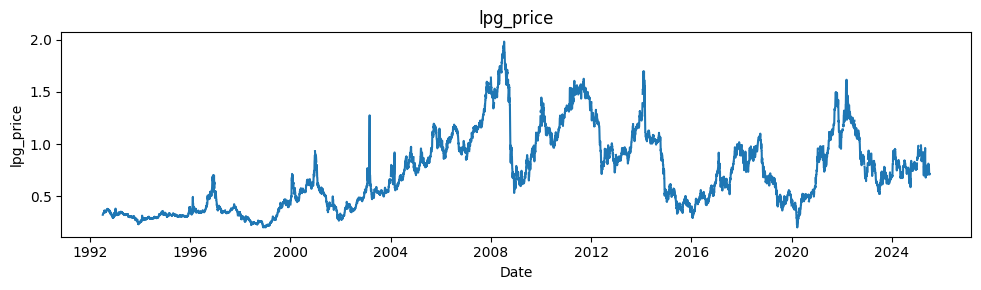

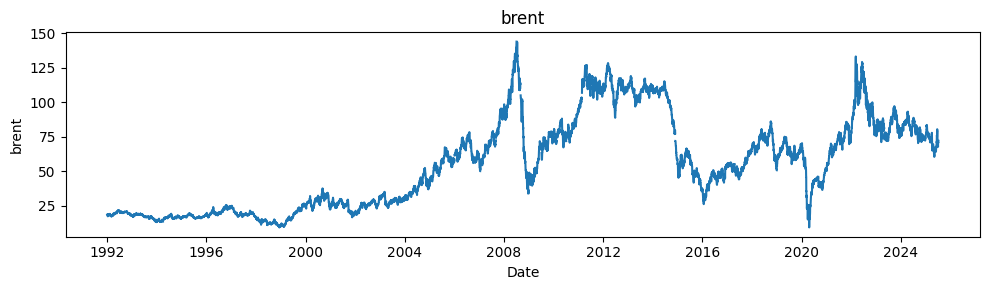

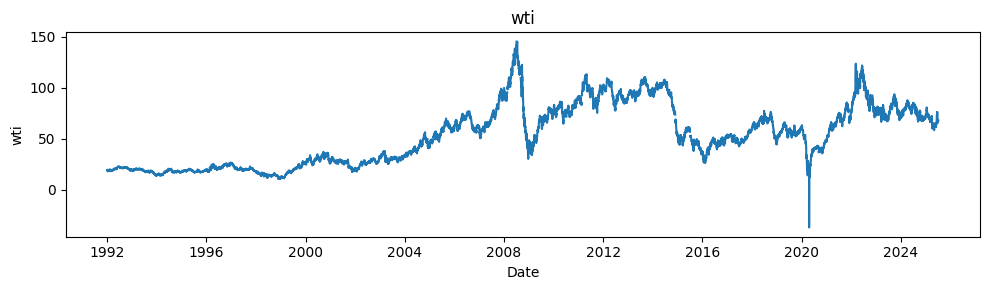

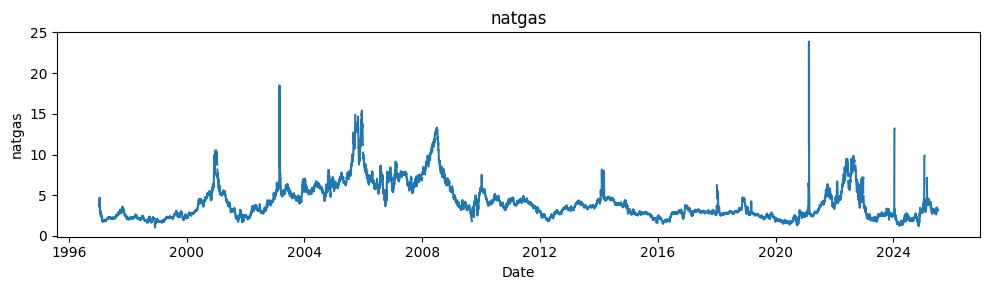

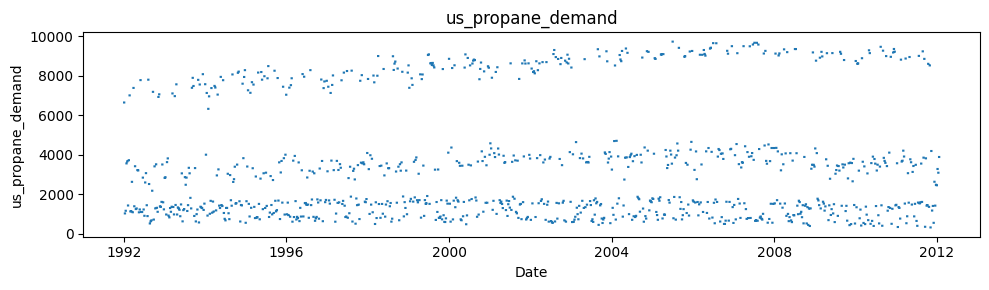

✔️  Exploration complete — scroll above to inspect the plots.


In [3]:


import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = Path("lpg_dataset.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE} not found. Run lpg_dataset_collector.py first.")


df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
print("Loaded", df.shape[0], "rows ×", df.shape[1], "columns")

na_counts = df.isna().sum()
print("\nMissing values per column:\n", na_counts)


for col in df.columns:
    plt.figure(figsize=(10, 3))           # one figure per series
    plt.plot(df.index, df[col])
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig("1.png")
    plt.show()



print("✔️  Exploration complete — scroll above to inspect the plots.")


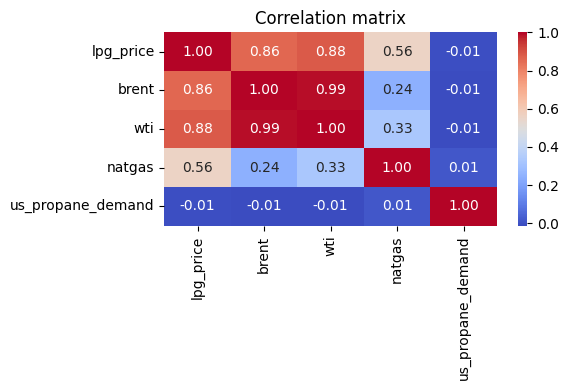

In [4]:

import numpy as np
import seaborn as sns 
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("correlationHM.png")
plt.show()

TRAIN size: 1434 weeks  |  VALID size: 290
                                     SARIMAX Results                                      
Dep. Variable:                          lpg_price   No. Observations:                 1434
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                2059.717
Date:                            Fri, 11 Jul 2025   AIC                          -4109.434
Time:                                    12:36:14   BIC                          -4083.481
Sample:                                07-10-1992   HQIC                         -4099.706
                                     - 12-27-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3481      0.369      0.943      0.346      -0.376     

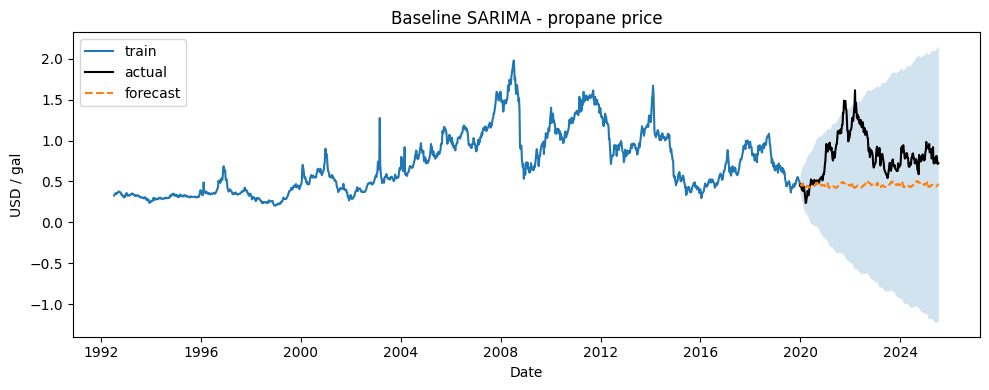

✔️  Baseline SARIMA complete — inspect plot & metrics above.


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

DATA_FILE = Path("lpg_dataset.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError("Run the collector script first to create lpg_dataset.csv")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
price = df["lpg_price"].dropna()


price_w = price.resample("W-FRI").last().dropna()


train_end = "2019-12-27"   # last Friday of 2019
train = price_w.loc[:train_end]
valid = price_w.loc[train_end:]

print("TRAIN size:", len(train), "weeks  |  VALID size:", len(valid))


order = (1, 1, 1)
seasonal_order = (1, 1, 1, 52)  

model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)
print(results.summary())



forecast = results.get_forecast(steps=len(valid))
fc_series = forecast.predicted_mean
conf_int = forecast.conf_int()


mae = mean_absolute_error(valid, fc_series)
mape = mean_absolute_percentage_error(valid, fc_series) * 100
print(f"\nMAE  : {mae:,.3f} USD/gal")
print(f"MAPE : {mape:,.2f} %")

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label="train")
plt.plot(valid.index, valid, label="actual", color="k")
plt.plot(fc_series.index, fc_series, label="forecast", linestyle="--")
plt.fill_between(fc_series.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.title("Baseline SARIMA ‑ propane price")
plt.xlabel("Date")
plt.ylabel("USD / gal")
plt.legend()
plt.tight_layout()
plt.show()

print("✔️  Baseline SARIMA complete — inspect plot & metrics above.")


Starting SARIMAX grid search...
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4017.8
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4495.3
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.6
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4466.9
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4016.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4122.6
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4483.4
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4019.9
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4514.2
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.7
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4510.8
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4015.0


C:\Users\Ryan Arrt7\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.3
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.4


C:\Users\Ryan Arrt7\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4483.2

Best SARIMAX order=(1, 1, 0), seasonal_order=(0, 1, 1, 52), AIC=-4514.2

Validation MAE:  0.377 USD/gal
Validation MAPE: 45.41 %


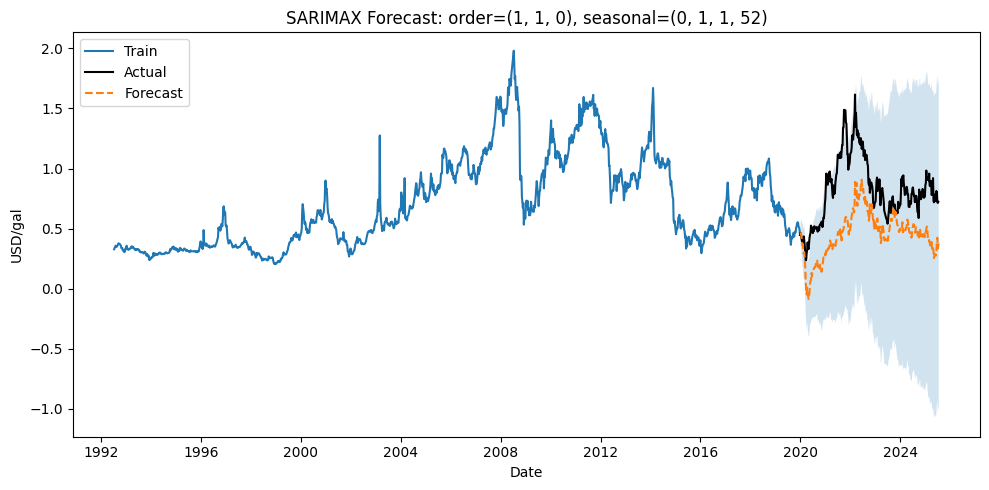

✔️ Grid search and forecast complete.


In [7]:
DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py to generate lpg_dataset.csv first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
# Weekly data (Friday)
y = df['lpg_price'].resample('W-FRI').last().dropna()
exog = df[['brent','wti']].resample('W-FRI').last().ffill()
# Align
data = pd.concat([y, exog], axis=1).dropna()
# Split
train_end = '2019-12-27'
train = data.loc[:train_end]
valid = data.loc[train_end:]
train_y, train_ex = train['lpg_price'], train[['brent','wti']]
valid_y, valid_ex = valid['lpg_price'], valid[['brent','wti']]

# Grid search SARIMAX parameters
d = D = 1
s = 52
best_aic = np.inf
best_params = None
print("Starting SARIMAX grid search...")
for p in [0,1]:
    for q in [0,1]:
        for P in [0,1]:
            for Q in [0,1]:
                try:
                    model = SARIMAX(
                        train_y,
                        exog=train_ex,
                        order=(p,d,q),
                        seasonal_order=(P,D,Q,s),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    aic = res.aic
                    print(f"Tested (p,d,q)=({p},{d},{q}) x (P,D,Q,s)=({P},{D},{Q},{s}) -> AIC={aic:.1f}")
                    if aic < best_aic:
                        best_aic = aic
                        best_params = ((p,d,q), (P,D,Q,s))
                except Exception as e:
                    continue

if best_params is None:
    raise RuntimeError("Grid search failed to fit any SARIMAX models.")
order, seasonal = best_params
print(f"\nBest SARIMAX order={order}, seasonal_order={seasonal}, AIC={best_aic:.1f}\n")

# Refit best model and forecast
best_model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
best_res = best_model.fit(disp=False)
fore = best_res.get_forecast(steps=len(valid_y), exog=valid_ex)
fc = fore.predicted_mean
ci = fore.conf_int()

# Evaluate\mae = mean_absolute_error(valid_y, fc)
mape = mean_absolute_percentage_error(valid_y, fc) * 100
print(f"Validation MAE:  {mae:.3f} USD/gal")
print(f"Validation MAPE: {mape:.2f} %")

# Plot results
plt.figure(figsize=(10,5))
plt.plot(train_y.index, train_y, label='Train')
plt.plot(valid_y.index, valid_y, label='Actual', color='k')
plt.plot(fc.index, fc, label='Forecast', linestyle='--')
plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.2)
plt.title(f"SARIMAX Forecast: order={order}, seasonal={seasonal}")
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Grid search and forecast complete.")

Starting SARIMAX grid search...
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4017.8
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4495.3
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.6
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4466.9
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4016.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4122.6
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4483.4
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4019.9
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4514.2
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.7
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4510.8
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4015.0
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.3
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.4
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=

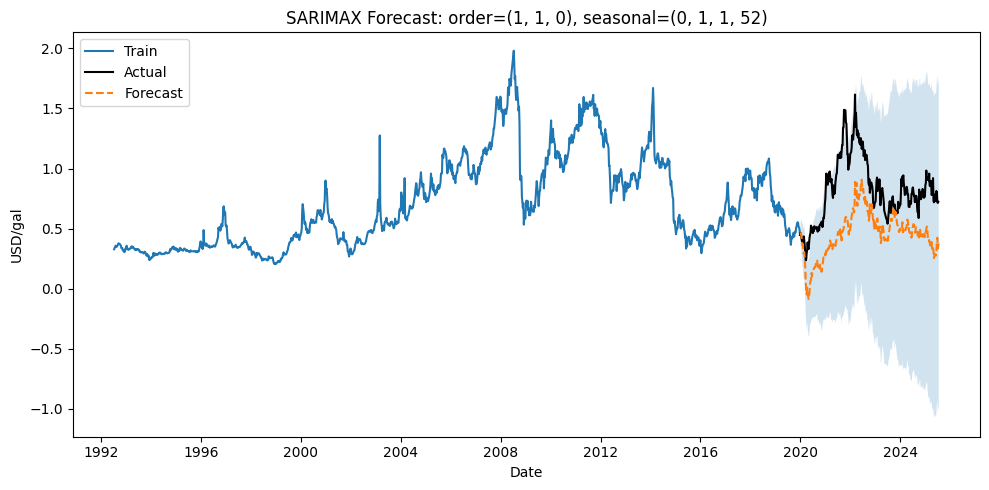

✔️ Grid search and forecast complete.


In [9]:
"""
manual grid search
"""
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py to generate lpg_dataset.csv first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)

# Weekly data (Friday)
y = df['lpg_price'].resample('W-FRI').last().dropna()
exog = df[['brent', 'wti']].resample('W-FRI').last().ffill()

# Align target and exogenous
data = pd.concat([y, exog], axis=1).dropna()

# Split into train / validation
train_end = '2019-12-27'
train = data.loc[:train_end]
valid = data.loc[train_end:]
train_y, train_ex = train['lpg_price'], train[['brent', 'wti']]
valid_y, valid_ex = valid['lpg_price'], valid[['brent', 'wti']]

# Grid search SARIMAX parameters
d = D = 1
s = 52
best_aic = np.inf
best_params = None
print("Starting SARIMAX grid search...")
for p in [0, 1]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    model = SARIMAX(
                        train_y,
                        exog=train_ex,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    aic = res.aic
                    print(f"Tested (p,d,q)=({p},{d},{q}) x (P,D,Q,s)=({P},{D},{Q},{s}) -> AIC={aic:.1f}")
                    if aic < best_aic:
                        best_aic = aic
                        best_params = ((p, d, q), (P, D, Q, s))
                except Exception:
                    continue

if best_params is None:
    raise RuntimeError("Grid search failed to fit any SARIMAX models.")

order, seasonal = best_params
print(f"\nBest SARIMAX order={order}, seasonal_order={seasonal}, AIC={best_aic:.1f}\n")

# Refit best model and forecast
best_model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
best_res = best_model.fit(disp=False)
forecast = best_res.get_forecast(steps=len(valid_y), exog=valid_ex)
fc = forecast.predicted_mean
ci = forecast.conf_int()

# Evaluate performance
mae = mean_absolute_error(valid_y, fc)
mape = mean_absolute_percentage_error(valid_y, fc) * 100
print(f"Validation MAE:  {mae:.3f} USD/gal")
print(f"Validation MAPE: {mape:.2f} %")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(train_y.index, train_y, label='Train')
plt.plot(valid_y.index, valid_y, label='Actual', color='k')
plt.plot(fc.index, fc, label='Forecast', linestyle='--')
plt.fill_between(fc.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2)
plt.title(f"SARIMAX Forecast: order={order}, seasonal={seasonal}")
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Grid search and forecast complete.")


Starting SARIMAX grid search...
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4017.8
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4495.3
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.6
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4466.9
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4016.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4122.6
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4483.4
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4019.9
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4514.2
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.7
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4510.8
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4015.0
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.3
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.4
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=

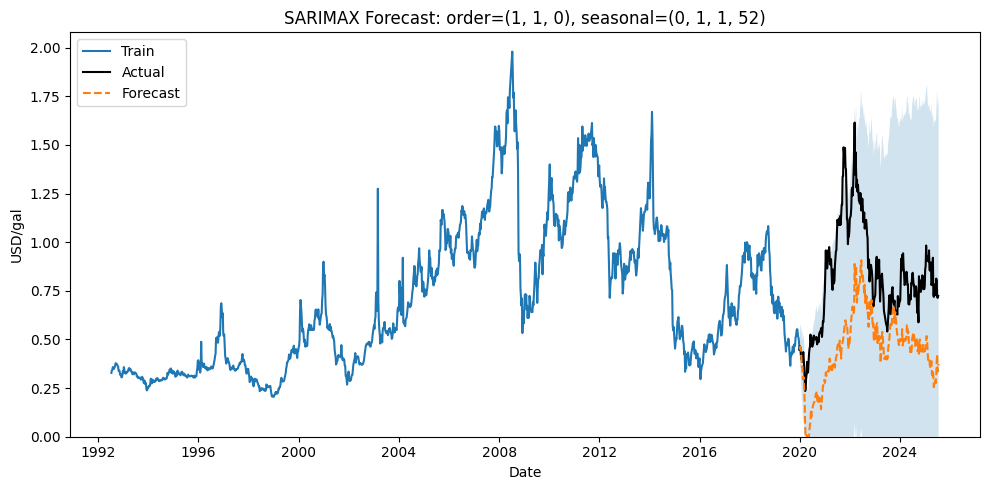

✔️ Grid search and forecast complete.


In [10]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Suppress convergence warnings for cleaner output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load and prepare data
DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py to generate lpg_dataset.csv first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)

# Weekly data (Friday)
y = df['lpg_price'].resample('W-FRI').last().dropna()
exog = df[['brent', 'wti']].resample('W-FRI').last().ffill()

# Align target and exogenous
data = pd.concat([y, exog], axis=1).dropna()

# Split into train / validation
train_end = '2019-12-27'
train = data.loc[:train_end]
valid = data.loc[train_end:]
train_y, train_ex = train['lpg_price'], train[['brent', 'wti']]
valid_y, valid_ex = valid['lpg_price'], valid[['brent', 'wti']]

# Grid search SARIMAX parameters
d = D = 1
s = 52
best_aic = np.inf
best_params = None
print("Starting SARIMAX grid search...")
for p in [0, 1]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    model = SARIMAX(
                        train_y,
                        exog=train_ex,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    aic = res.aic
                    print(f"Tested (p,d,q)=({p},{d},{q}) x (P,D,Q,s)=({P},{D},{Q},{s}) -> AIC={aic:.1f}")
                    if aic < best_aic:
                        best_aic = aic
                        best_params = ((p, d, q), (P, D, Q, s))
                except Exception:
                    continue

if best_params is None:
    raise RuntimeError("Grid search failed to fit any SARIMAX models.")

order, seasonal = best_params
print(f"\nBest SARIMAX order={order}, seasonal_order={seasonal}, AIC={best_aic:.1f}\n")

# Refit best model and forecast
best_model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
best_res = best_model.fit(disp=False)
forecast = best_res.get_forecast(steps=len(valid_y), exog=valid_ex)
fc = forecast.predicted_mean
ci = forecast.conf_int()

# Enforce non-negative forecasts
fc = fc.clip(lower=0.0)
ci_lower = ci.iloc[:, 0].clip(lower=0.0)
ci_upper = ci.iloc[:, 1].clip(lower=0.0)

# Evaluate performance
mae = mean_absolute_error(valid_y, fc)
mape = mean_absolute_percentage_error(valid_y, fc) * 100
print(f"Validation MAE:  {mae:.3f} USD/gal")
print(f"Validation MAPE: {mape:.2f} %")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(train_y.index, train_y, label='Train')
plt.plot(valid_y.index, valid_y, label='Actual', color='k')
plt.plot(fc.index, fc, label='Forecast', linestyle='--')
plt.fill_between(fc.index, ci_lower, ci_upper, alpha=0.2)
plt.title(f"SARIMAX Forecast: order={order}, seasonal={seasonal}")
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Grid search and forecast complete.")


Starting SARIMAX grid search...
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4017.8
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4495.3
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.6
Tested (p,d,q)=(0,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4466.9
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4016.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.4
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4122.6
Tested (p,d,q)=(0,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4483.4
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4019.9
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4514.2
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.7
Tested (p,d,q)=(1,1,0) x (P,D,Q,s)=(1,1,1,52) -> AIC=-4510.8
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,0,52) -> AIC=-4015.0
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(0,1,1,52) -> AIC=-4513.3
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,0,52) -> AIC=-4117.4
Tested (p,d,q)=(1,1,1) x (P,D,Q,s)=(1,1,1,52) -> AIC=

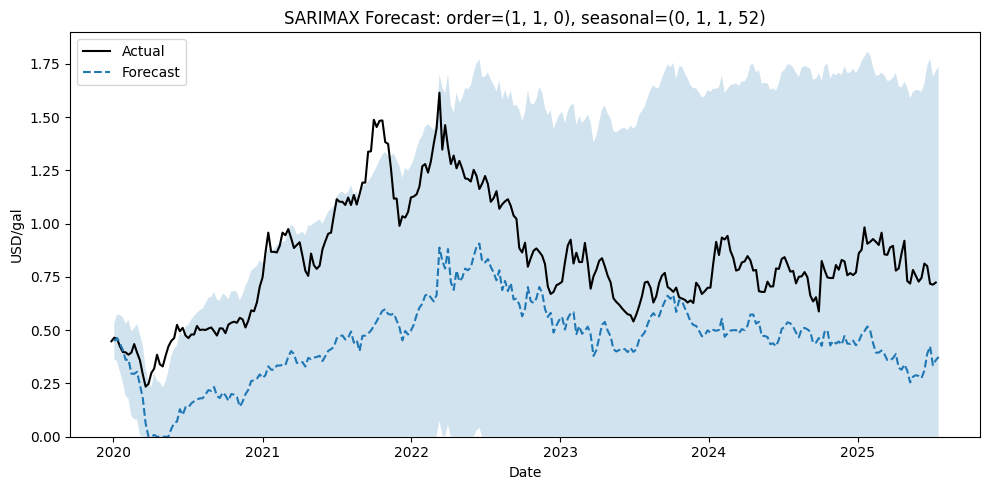

✔️ Grid search and forecast complete.


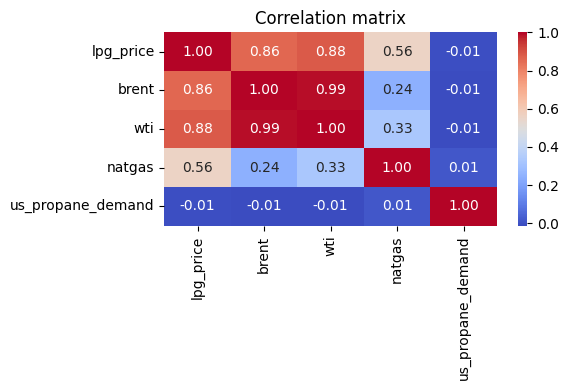

✔️  Exploration complete — scroll above to inspect the plots.


In [1]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py to generate lpg_dataset.csv first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)

# Weekly data (Friday)
y = df['lpg_price'].resample('W-FRI').last().dropna()
exog = df[['brent', 'wti']].resample('W-FRI').last().ffill()

data = pd.concat([y, exog], axis=1).dropna()

# Split into train / validation
train_end = '2019-12-27'
train = data.loc[:train_end]
valid = data.loc[train_end:]
train_y, train_ex = train['lpg_price'], train[['brent', 'wti']]
valid_y, valid_ex = valid['lpg_price'], valid[['brent', 'wti']]

# Grid search SARIMAX parameters
d = D = 1
s = 52
best_aic = np.inf
best_params = None
print("Starting SARIMAX grid search...")
for p in [0, 1]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    model = SARIMAX(
                        train_y,
                        exog=train_ex,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    aic = res.aic
                    print(f"Tested (p,d,q)=({p},{d},{q}) x (P,D,Q,s)=({P},{D},{Q},{s}) -> AIC={aic:.1f}")
                    if aic < best_aic:
                        best_aic = aic
                        best_params = ((p, d, q), (P, D, Q, s))
                except Exception:
                    continue

if best_params is None:
    raise RuntimeError("Grid search failed to fit any SARIMAX models.")

order, seasonal = best_params
print(f"\nBest SARIMAX order={order}, seasonal_order={seasonal}, AIC={best_aic:.1f}\n")

best_model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
best_res = best_model.fit(disp=False)
forecast = best_res.get_forecast(steps=len(valid_y), exog=valid_ex)
fc = forecast.predicted_mean
ci = forecast.conf_int()

# Enforce non-negative forecasts
fc = fc.clip(lower=0.0)
ci_lower = ci.iloc[:, 0].clip(lower=0.0)
ci_upper = ci.iloc[:, 1].clip(lower=0.0)

# Save SARIMAX predictions for ensemble
pred_df = pd.DataFrame({'forecast': fc}, index=fc.index)
pred_df.to_csv('lpg_sarimax_predictions.csv')
print(" Saved SARIMAX predictions to lpg_sarimax_predictions.csv")

mae = mean_absolute_error(valid_y, fc)
mape = mean_absolute_percentage_error(valid_y, fc) * 100
print(f"Validation MAE:  {mae:.3f} USD/gal")
print(f"Validation MAPE: {mape:.2f} %")

plt.figure(figsize=(10, 5))
plt.plot(train_y.index, train_y, label='Train')
plt.plot(valid_y.index, valid_y, label='Actual', color='k')
plt.plot(fc.index, fc, label='Forecast', linestyle='--')
plt.fill_between(fc.index, ci_lower, ci_upper, alpha=0.2)
plt.title(f"SARIMAX Forecast: order={order}, seasonal={seasonal}")
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Grid search and forecast complete.")
# 4. Correlation heatmap
import numpy as np
import seaborn as sns 
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

print(" Exploration complete .")


# 2. LSTM model





Epoch 1/20

89/89 - 4s - loss: 0.0132 - val_loss: 0.0036 - 4s/epoch - 45ms/step
Epoch 2/20
89/89 - 1s - loss: 0.0026 - val_loss: 0.0034 - 634ms/epoch - 7ms/step
Epoch 3/20
89/89 - 1s - loss: 0.0023 - val_loss: 0.0030 - 535ms/epoch - 6ms/step
Epoch 4/20
89/89 - 1s - loss: 0.0021 - val_loss: 0.0028 - 514ms/epoch - 6ms/step
Epoch 5/20
89/89 - 1s - loss: 0.0020 - val_loss: 0.0030 - 748ms/epoch - 8ms/step
Epoch 6/20
89/89 - 1s - loss: 0.0019 - val_loss: 0.0028 - 553ms/epoch - 6ms/step
Epoch 7/20
89/89 - 1s - loss: 0.0016 - val_loss: 0.0026 - 534ms/epoch - 6ms/step
Epoch 8/20
89/89 - 1s - loss: 0.0014 - val_loss: 0.0019 - 524ms/epoch - 6ms/step
Epoch 9/20
89/89 - 1s - loss: 0.0014 - val_loss: 0.0019 - 528ms/epoch - 6ms/step
Epoch 10/20
89/89 - 1s - loss: 0.0013 - val_loss: 0.0018 - 551ms/epoch - 6ms/step
Epoch 11/20
89/89 - 1s - loss: 0.0013 - val_loss: 0.0019 - 550ms/epoch - 6ms/step
Epoch 12/20
89/89 - 1s - loss: 0.0012 - val_loss: 0.0016 - 522ms/epoch - 6ms/step
Epoch 13/20
89/89 - 1s 

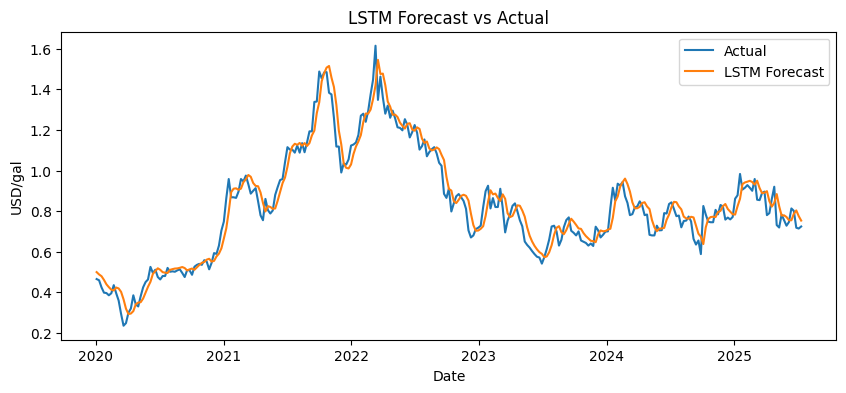

✔️ LSTM model complete.


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Load weekly data
DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
y = df['lpg_price'].resample('W-FRI').last().dropna().to_frame()

# 2. Scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(y)

def create_sequences(data, lookback=12):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

# 3. Sequences
lookback = 12
X, Y = create_sequences(scaled, lookback)

# 4. Train/test split indices
split = np.where(y.index >= '2020-01-01')[0][0] - lookback
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# 5. Build LSTM
model = Sequential([
    LSTM(32, input_shape=(lookback,1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 6. Train
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, Y_test),
    verbose=2
)

# 7. Forecast
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
actual = y.values[lookback+split:]

# Metrics
mae = mean_absolute_error(actual, pred)
mape = mean_absolute_percentage_error(actual, pred)*100
print(f"LSTM MAE: {mae:.3f} USD/gal, MAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(10,4))
plt.plot(y.index[lookback+split:], actual, label='Actual')
plt.plot(y.index[lookback+split:], pred, label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.show()

print("✔️ LSTM model complete.")


# LSTM + SArimax grid search




Epoch 1/20

89/89 - 3s - loss: 0.0134 - val_loss: 0.0044 - 3s/epoch - 35ms/step
Epoch 2/20
89/89 - 1s - loss: 0.0030 - val_loss: 0.0044 - 529ms/epoch - 6ms/step
Epoch 3/20
89/89 - 0s - loss: 0.0025 - val_loss: 0.0033 - 497ms/epoch - 6ms/step
Epoch 4/20
89/89 - 1s - loss: 0.0024 - val_loss: 0.0031 - 518ms/epoch - 6ms/step
Epoch 5/20
89/89 - 1s - loss: 0.0019 - val_loss: 0.0028 - 516ms/epoch - 6ms/step
Epoch 6/20
89/89 - 1s - loss: 0.0017 - val_loss: 0.0023 - 505ms/epoch - 6ms/step
Epoch 7/20
89/89 - 0s - loss: 0.0017 - val_loss: 0.0023 - 472ms/epoch - 5ms/step
Epoch 8/20
89/89 - 1s - loss: 0.0015 - val_loss: 0.0022 - 546ms/epoch - 6ms/step
Epoch 9/20
89/89 - 0s - loss: 0.0014 - val_loss: 0.0021 - 497ms/epoch - 6ms/step
Epoch 10/20
89/89 - 1s - loss: 0.0014 - val_loss: 0.0020 - 651ms/epoch - 7ms/step
Epoch 11/20
89/89 - 0s - loss: 0.0013 - val_loss: 0.0021 - 488ms/epoch - 5ms/step
Epoch 12/20
89/89 - 0s - loss: 0.0013 - val_loss: 0.0018 - 495ms/epoch - 6ms/step
Epoch 13/20
89/89 - 0s 

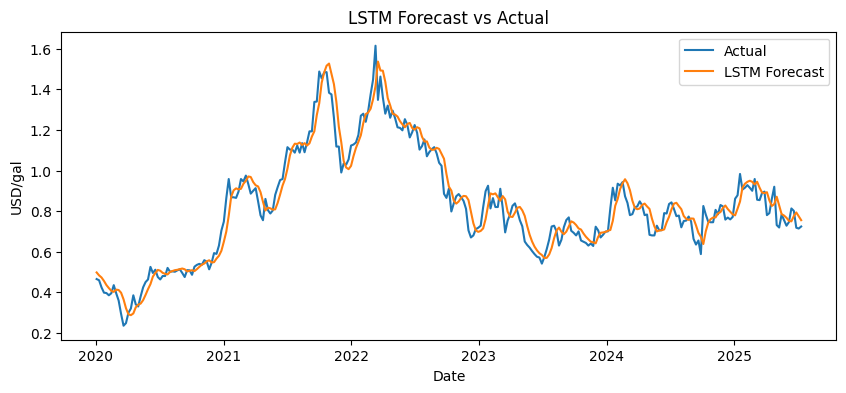

✔️ LSTM model complete.


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
y = df['lpg_price'].resample('W-FRI').last().dropna().to_frame()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(y)

def create_sequences(data, lookback=12):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

lookback = 12
X, Y = create_sequences(scaled, lookback)

split = np.where(y.index >= '2020-01-01')[0][0] - lookback
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

#LSTM
model = Sequential([
    LSTM(32, input_shape=(lookback, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

#Train
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, Y_test),
    verbose=2
)

# Forecast
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
actual = y.values[lookback+split:]

# Metrics
mae = mean_absolute_error(actual, pred)
mape = mean_absolute_percentage_error(actual, pred) * 100
print(f"LSTM MAE: {mae:.3f} USD/gal, MAPE: {mape:.2f}%")

pred_index = y.index[lookback+split:]
pred_df = pd.DataFrame({'forecast': pred.flatten()}, index=pred_index)
pred_df.to_csv('lpg_lstm_predictions.csv')
print(" Saved LSTM predictions to lpg_lstm_predictions.csv")

# Plot
plt.figure(figsize=(10,4))
plt.plot(pred_index, actual, label='Actual')
plt.plot(pred_index, pred, label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.show()

print("✔️ LSTM model complete.")


Individual model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
Using inverse-MAE weights: {'sarimax': 0.12232695063783776, 'lstm': 0.8776730493621622}
Ensemble MAE : 0.061 USD/gal
Ensemble MAPE: 7.67 %


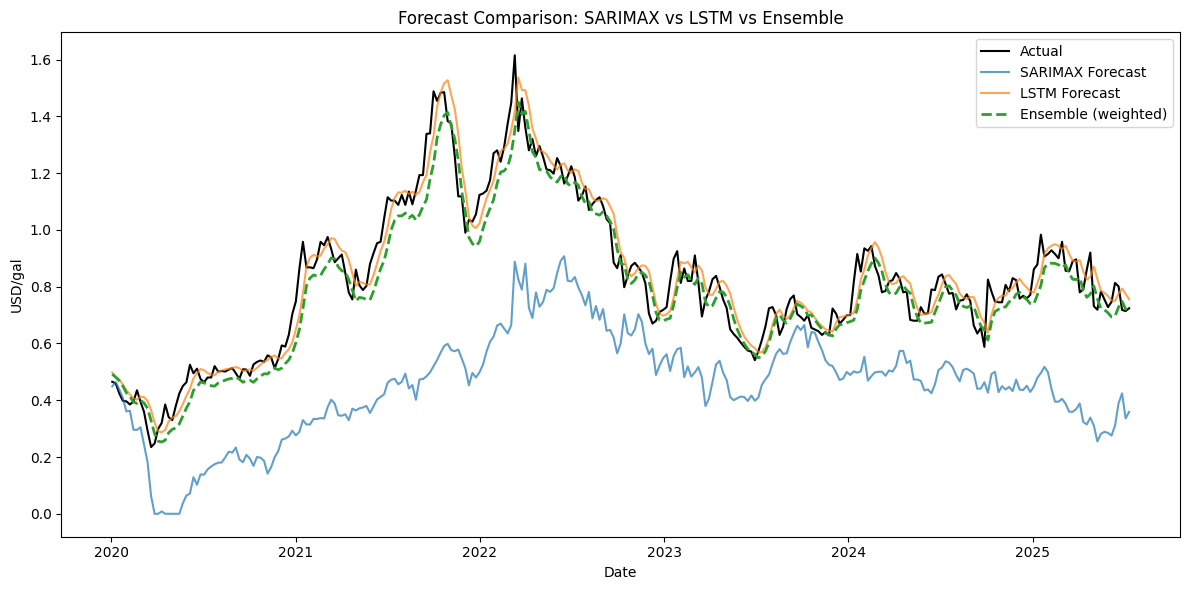

✔️ Ensemble evaluation complete.


In [2]:
"""
LPG Forecasting · Model Ensemble
"""
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from pathlib import Path

sarimax = pd.read_csv(
    "lpg_sarimax_predictions.csv", index_col=0, parse_dates=True
).rename(columns={'forecast':'sarimax'})
lstm = pd.read_csv(
    "lpg_lstm_predictions.csv",   index_col=0, parse_dates=True
).rename(columns={'forecast':'lstm'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

ensemble_df = pd.concat([
    actual.rename('lpg_price'),
    sarimax['sarimax'],
    lstm['lstm']
], axis=1, join='inner').dropna()

metrics = {}
for model in ['sarimax','lstm']:
    mae = mean_absolute_error(
        ensemble_df['lpg_price'], ensemble_df[model]
    )
    mape = mean_absolute_percentage_error(
        ensemble_df['lpg_price'], ensemble_df[model]
    ) * 100
    metrics[model] = {'MAE': mae, 'MAPE': mape}

metrics_df = pd.DataFrame(metrics).T
print("Individual model performance (2020–present):")
print(metrics_df)

#  Compute inverse-error weights 
errors = metrics_df['MAE'].to_dict()
inv = {m: 1/e if e>0 else 0 for m,e in errors.items()}
total = sum(inv.values())
weights = {m: inv[m]/total for m in inv}
print(f"Using inverse-MAE weights: {weights}")

#ensemble forecast and evaluate
ensemble_df['ensemble'] = (
    ensemble_df['sarimax'] * weights['sarimax'] +
    ensemble_df['lstm']    * weights['lstm']
)
# Evaluate ensemble
mae = mean_absolute_error(
    ensemble_df['lpg_price'], ensemble_df['ensemble']
)
mape = mean_absolute_percentage_error(
    ensemble_df['lpg_price'], ensemble_df['ensemble']
) * 100
print(f"Ensemble MAE : {mae:.3f} USD/gal")
print(f"Ensemble MAPE: {mape:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(ensemble_df.index, ensemble_df['lpg_price'], label='Actual', color='k')
plt.plot(ensemble_df.index, ensemble_df['sarimax'], label='SARIMAX Forecast', alpha=0.7)
plt.plot(ensemble_df.index, ensemble_df['lstm'], label='LSTM Forecast', alpha=0.7)
plt.plot(ensemble_df.index, ensemble_df['ensemble'],
         label='Ensemble (weighted)', linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Ensemble evaluation complete.")


# adjusted weights grid search over alpha

Individual model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
Optimal weight for LSTM (α): 0.98  (MAE: 0.051)
Ensemble MAE : 0.051 USD/gal
Ensemble MAPE: 6.60 %


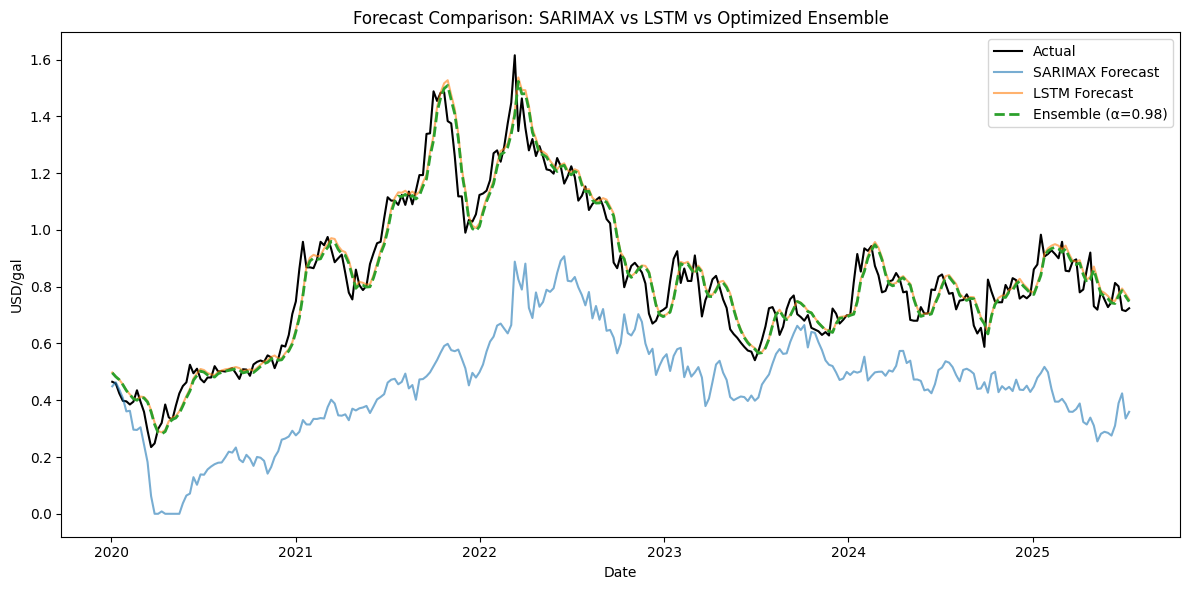

✔️ Optimized ensemble evaluation complete.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from pathlib import Path

darimax_file = Path("lpg_sarimax_predictions.csv")
lstm_file   = Path("lpg_lstm_predictions.csv")

sarimax = pd.read_csv(darimax_file, index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm   = pd.read_csv(lstm_file,   index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

# Align series with inner join
ensemble_df = pd.concat([
    actual.rename('lpg_price'),
    sarimax['sarimax'],
    lstm['lstm']
], axis=1, join='inner').dropna()

metrics = {}
for model in ['sarimax','lstm']:
    mae = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df[model])
    mape = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df[model]) * 100
    metrics[model] = {'MAE': mae, 'MAPE': mape}
metrics_df = pd.DataFrame(metrics).T
print("Individual model performance (2020–present):")
print(metrics_df)

# Grid-search ensemble weight α,0
alphas = np.linspace(0,1,51)
best_mae = np.inf
best_alpha = None
for alpha in alphas:
    ensemble_pred = alpha * ensemble_df['lstm'] + (1-alpha) * ensemble_df['sarimax']
    mae = mean_absolute_error(ensemble_df['lpg_price'], ensemble_pred)
    if mae < best_mae:
        best_mae = mae
        best_alpha = alpha
print(f"Optimal weight for LSTM (α): {best_alpha:.2f}  (MAE: {best_mae:.3f})")

ensemble_df['ensemble'] = best_alpha * ensemble_df['lstm'] + (1-best_alpha) * ensemble_df['sarimax']
mae_en = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df['ensemble'])
mape_en = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df['ensemble']) * 100
print(f"Ensemble MAE : {mae_en:.3f} USD/gal")
print(f"Ensemble MAPE: {mape_en:.2f} %")

# 7. Plot results -----------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(ensemble_df.index, ensemble_df['lpg_price'], label='Actual', color='k')
plt.plot(ensemble_df.index, ensemble_df['sarimax'], label='SARIMAX Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['lstm'], label='LSTM Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['ensemble'], label=f'Ensemble (α={best_alpha:.2f})', linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs Optimized Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Optimized ensemble evaluation complete.")


# Two-stage grid-search ensemble weight α

Individual model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
Coarse optimal α: 0.980 (MAE: 0.051)
Refined optimal α: 0.9756 (MAE: 0.051)
Ensemble MAE : 0.051 USD/gal
Ensemble MAPE: 6.60 %


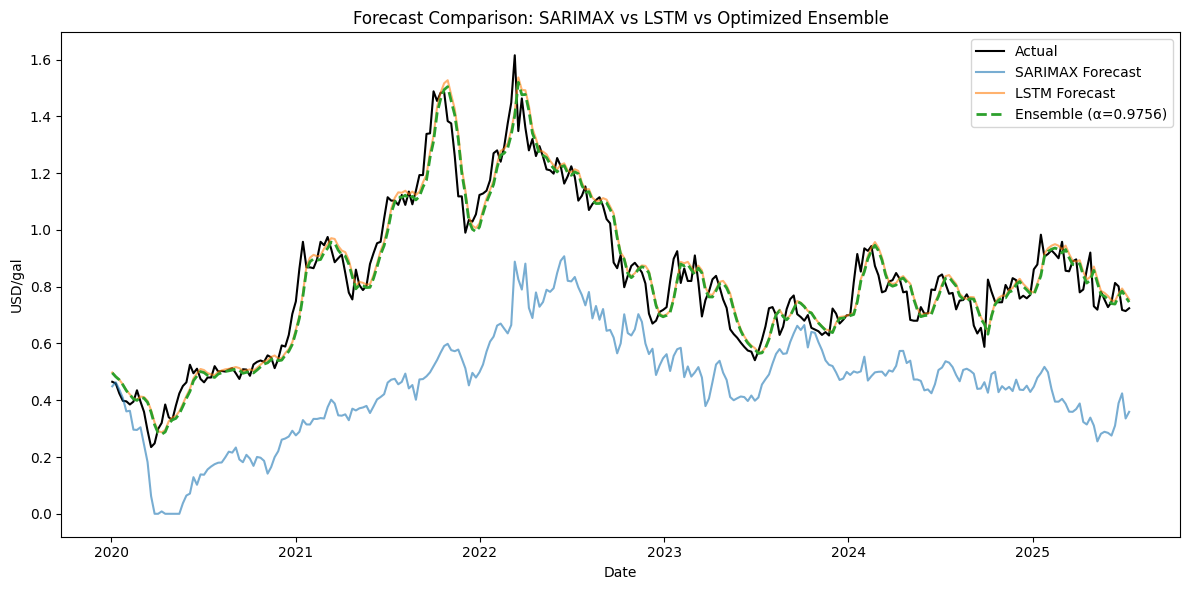

✔️ Optimized ensemble evaluation complete.


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from pathlib import Path

darimax_file = Path("lpg_sarimax_predictions.csv")
sarimax_file = darimax_file
lstm_file   = Path("lpg_lstm_predictions.csv")

sarimax = pd.read_csv(sarimax_file, index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(lstm_file, index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

ensemble_df = pd.concat([
    actual.rename('lpg_price'),
    sarimax['sarimax'],
    lstm['lstm']
], axis=1, join='inner').dropna()

metrics = {}
for model in ['sarimax','lstm']:
    mae = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df[model])
    mape = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df[model]) * 100
    metrics[model] = {'MAE': mae, 'MAPE': mape}
metrics_df = pd.DataFrame(metrics).T
print("Individual model performance (2020–present):")
print(metrics_df)

# Two-stage grid-search ensemble weight α
# Stage 1: coarse search over [0,1]
coarse_alphas = np.linspace(0, 1, 51)
best_mae = np.inf
best_alpha = None
for alpha in coarse_alphas:
    ens_pred = alpha * ensemble_df['lstm'] + (1 - alpha) * ensemble_df['sarimax']
    mae = mean_absolute_error(ensemble_df['lpg_price'], ens_pred)
    if mae < best_mae:
        best_mae = mae
        best_alpha = alpha
print(f"Coarse optimal α: {best_alpha:.3f} (MAE: {best_mae:.3f})")

# Stage 2: fine search around coarse best (± step)
step = coarse_alphas[1] - coarse_alphas[0]
low = max(0, best_alpha - step)
high = min(1, best_alpha + step)
fine_alphas = np.linspace(low, high, 201)
best_mae_fine = np.inf
best_alpha_fine = None
for alpha in fine_alphas:
    ens_pred = alpha * ensemble_df['lstm'] + (1 - alpha) * ensemble_df['sarimax']
    mae = mean_absolute_error(ensemble_df['lpg_price'], ens_pred)
    if mae < best_mae_fine:
        best_mae_fine = mae
        best_alpha_fine = alpha
print(f"Refined optimal α: {best_alpha_fine:.4f} (MAE: {best_mae_fine:.3f})")

best_alpha = best_alpha_fine
ensemble_df['ensemble'] = best_alpha * ensemble_df['lstm'] + (1 - best_alpha) * ensemble_df['sarimax']
mae_en = mean_absolute_error(ensemble_df['lpg_price'], ensemble_df['ensemble'])
mape_en = mean_absolute_percentage_error(ensemble_df['lpg_price'], ensemble_df['ensemble']) * 100
print(f"Ensemble MAE : {mae_en:.3f} USD/gal")
print(f"Ensemble MAPE: {mape_en:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(ensemble_df.index, ensemble_df['lpg_price'], label='Actual', color='k')
plt.plot(ensemble_df.index, ensemble_df['sarimax'], label='SARIMAX Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['lstm'], label='LSTM Forecast', alpha=0.6)
plt.plot(ensemble_df.index, ensemble_df['ensemble'], label=f'Ensemble (α={best_alpha:.4f})', linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs Optimized Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Optimized ensemble evaluation complete.")


Train weeks: 1434, Validation weeks: 290


C:\Users\Ryan Arrt7\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                          lpg_price   No. Observations:                 1434
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                2248.581
Date:                            Thu, 24 Jul 2025   AIC                          -4483.162
Time:                                    04:32:19   BIC                          -4446.827
Sample:                                07-10-1992   HQIC                         -4469.543
                                     - 12-27-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
brent          0.0065      0.001      7.974      0.000       0.005       0.008
wti            0.0031      0.001   

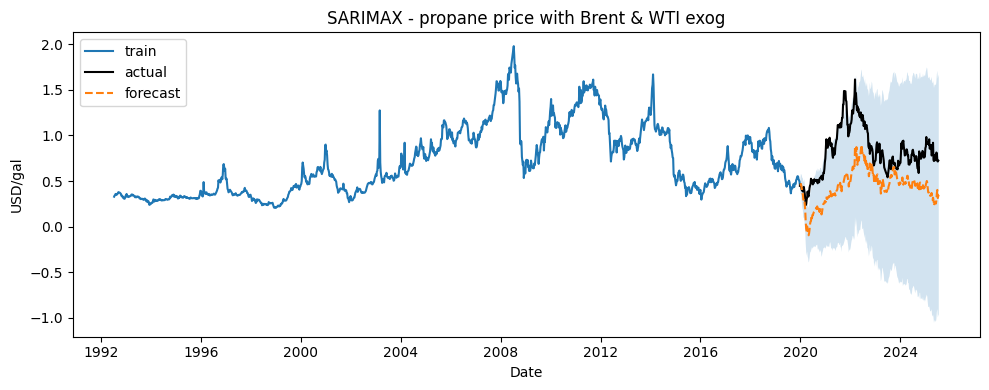

✔️  SARIMAX complete — inspect plot & metrics above.


NameError: name 'acorr_ljungbox' is not defined

In [3]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Run the collector script first to create lpg_dataset.csv")


df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
# target series
y = df["lpg_price"].dropna()
# exogenous: Brent, WTI
exog = df[["brent", "wti"]].ffill().dropna()

y_w = y.resample("W-FRI").last()
exog_w = exog.resample("W-FRI").last()

data = pd.concat([y_w, exog_w], axis=1).dropna()

y_w, exog_w = data["lpg_price"], data[["brent", "wti"]]

train_end = "2019-12-27"
train_y = y_w.loc[:train_end]
train_ex = exog_w.loc[:train_end]
valid_y = y_w.loc[train_end:]
valid_ex = exog_w.loc[train_end:]

print(f"Train weeks: {len(train_y)}, Validation weeks: {len(valid_y)}")

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 52)
model = SARIMAX(
    train_y,
    exog=train_ex,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary())

steps = len(valid_y)
fc = results.get_forecast(steps=steps, exog=valid_ex)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

mae = mean_absolute_error(valid_y, fc_mean)
mape = mean_absolute_percentage_error(valid_y, fc_mean) * 100
print(f"\nSARIMAX MAE  : {mae:.3f} USD/gal")
print(f"SARIMAX MAPE : {mape:.2f} %")

plt.figure(figsize=(10,4))
plt.plot(train_y.index, train_y, label="train")
plt.plot(valid_y.index, valid_y, label="actual", color="k")
plt.plot(fc_mean.index, fc_mean, label="forecast", linestyle="--")
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2)
plt.title("SARIMAX - propane price with Brent & WTI exog")
plt.xlabel("Date")
plt.ylabel("USD/gal")
plt.legend()
plt.tight_layout()
plt.show()

print("✔️  SARIMAX complete — inspect plot & metrics above.")

from statsmodels.tsa.statespace.sarimax import SARIMAXResults  
import joblib

SAVE_DIR   = Path('.')
MODEL_PATH = SAVE_DIR / 'lpg_sarimax_model.pkl'   
PRED_PATH  = SAVE_DIR / 'lpg_sarimax_predictions.csv'  
RESID_PATH = SAVE_DIR / 'lpg_sarimax_residuals.csv'

results.save(MODEL_PATH)
pd.DataFrame({'forecast': fc_mean}, index=fc_mean.index).to_csv(PRED_PATH)

residuals = results.resid.dropna()
residuals.to_csv(RESID_PATH, header=['residual'])

lb = acorr_ljungbox(residuals, lags=[12, 24, 52], return_df=True)
print('Residual Ljung–Box p-values (lags 12/24/52):')
print(lb['lb_pvalue'].values)

# XGBoost

Saved XGBoost model to lpg_xgboost_model.pkl
XGBoost MAE: 0.044 USD/gal, MAPE: 5.65%
✅ Saved XGBoost predictions to lpg_xgboost_predictions.csv


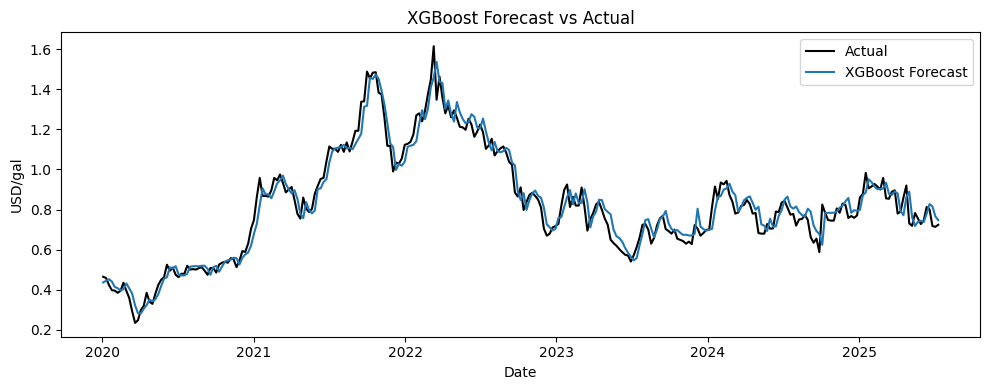

✔️ XGBoost model complete.


In [2]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py first to fetch data.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
weekly = df.resample('W-FRI').last().ffill()

target = weekly['lpg_price']
exog = weekly[['brent', 'wti', 'us_propane_demand']]

n_lags = 4
lags = pd.concat(
    [target.shift(i).rename(f'lag_{i}') for i in range(1, n_lags+1)],
    axis=1
)
X_full = pd.concat([lags, exog], axis=1).dropna()
y_full = target.loc[X_full.index]

split_date = '2020-01-01'
X_train = X_full.loc[:split_date]
y_train = y_full.loc[:split_date]
X_test  = X_full.loc[split_date:]
y_test  = y_full.loc[split_date:]

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)
joblib.dump(model, 'lpg_xgboost_model.pkl')
print("Saved XGBoost model to lpg_xgboost_model.pkl")

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred) * 100
print(f"XGBoost MAE: {mae:.3f} USD/gal, MAPE: {mape:.2f}%")

pd.DataFrame({'forecast': pred}, index=y_test.index).to_csv('lpg_xgboost_predictions.csv')
print("✅ Saved XGBoost predictions to lpg_xgboost_predictions.csv")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label='Actual', color='k')
plt.plot(y_test.index, pred, label='XGBoost Forecast')
plt.title('XGBoost Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ XGBoost model complete.")

Base model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
xgb      0.043517   5.650992
Optimal α (LSTM)=0.00, β (XGB)=1.00  -> MAE=0.044
Ensemble MAE : 0.044 USD/gal
Ensemble MAPE: 5.65 %


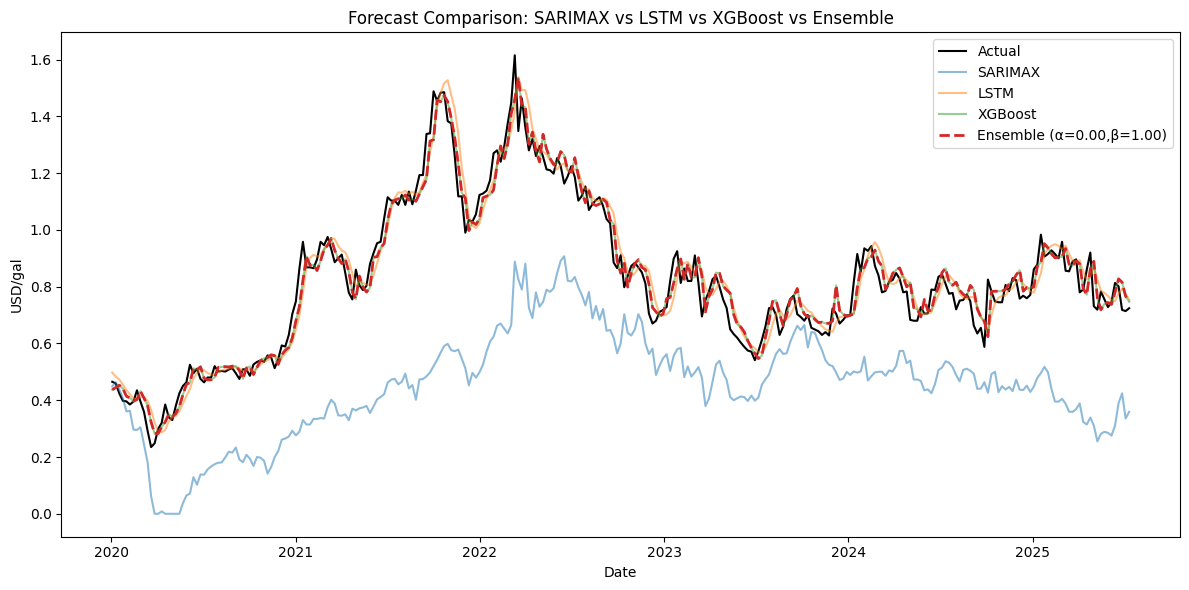

✔️ Model comparison & ensemble complete.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

sarimax_file = Path("lpg_sarimax_predictions.csv")
lstm_file    = Path("lpg_lstm_predictions.csv")
xgb_file     = Path("lpg_xgboost_predictions.csv")

sarimax = pd.read_csv(sarimax_file, index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(lstm_file,    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(xgb_file,     index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

#Align with inner join
df_all = pd.concat([actual.rename('actual'), sarimax['sarimax'], lstm['lstm'], xgb['xgb']],
                   axis=1, join='inner').dropna()

#base model metrics
metrics = {}
for m in ['sarimax','lstm','xgb']:
    mae  = mean_absolute_error(df_all['actual'], df_all[m])
    mape = mean_absolute_percentage_error(df_all['actual'], df_all[m]) * 100
    metrics[m] = {'MAE': mae, 'MAPE': mape}
metrics_df = pd.DataFrame(metrics).T
print("Base model performance (2020–present):")
print(metrics_df)

# Grid-search ensemble weights α, β
alphas = np.linspace(0,1,41)
betas  = np.linspace(0,1,41)
best_mae = np.inf
best_ab = (0,0)
for alpha in alphas:
    for beta in betas:
        if alpha + beta > 1: continue
        ens = alpha*df_all['lstm'] + beta*df_all['xgb'] + (1-alpha-beta)*df_all['sarimax']
        mae = mean_absolute_error(df_all['actual'], ens)
        if mae < best_mae:
            best_mae = mae
            best_ab = (alpha, beta)
alpha_opt, beta_opt = best_ab
print(f"Optimal α (LSTM)={alpha_opt:.2f}, β (XGB)={beta_opt:.2f}  -> MAE={best_mae:.3f}")

df_all['ensemble'] = alpha_opt*df_all['lstm'] + beta_opt*df_all['xgb'] + (1-alpha_opt-beta_opt)*df_all['sarimax']
mae_en  = mean_absolute_error(df_all['actual'], df_all['ensemble'])
mape_en = mean_absolute_percentage_error(df_all['actual'], df_all['ensemble']) * 100
print(f"Ensemble MAE : {mae_en:.3f} USD/gal")
print(f"Ensemble MAPE: {mape_en:.2f} %")

#forecasts + ensemble
plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'], label='SARIMAX', alpha=0.5)
plt.plot(df_all.index, df_all['lstm'],    label='LSTM',    alpha=0.5)
plt.plot(df_all.index, df_all['xgb'],     label='XGBoost', alpha=0.5)
plt.plot(df_all.index, df_all['ensemble'], label=f'Ensemble (α={alpha_opt:.2f},β={beta_opt:.2f})',
         linestyle='--', linewidth=2)
plt.title('Forecast Comparison: SARIMAX vs LSTM vs XGBoost vs Ensemble')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Model comparison & ensemble complete.")


# xg Stacking meta-learner (RidgeCV)

Base model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
xgb      0.043517   5.650992 

Optimal linear ensemble: α (LSTM)=0.00, β (XGB)=1.00 -> MAE=0.044
Linear Ensemble MAE : 0.044 USD/gal
Linear Ensemble MAPE: 5.65 %

Stacking weights: SARIMAX=-0.091, LSTM=-0.078, XGB=1.122, intercept=-0.002
Stacking MAE : 0.041 USD/gal
Stacking MAPE: 5.35 %



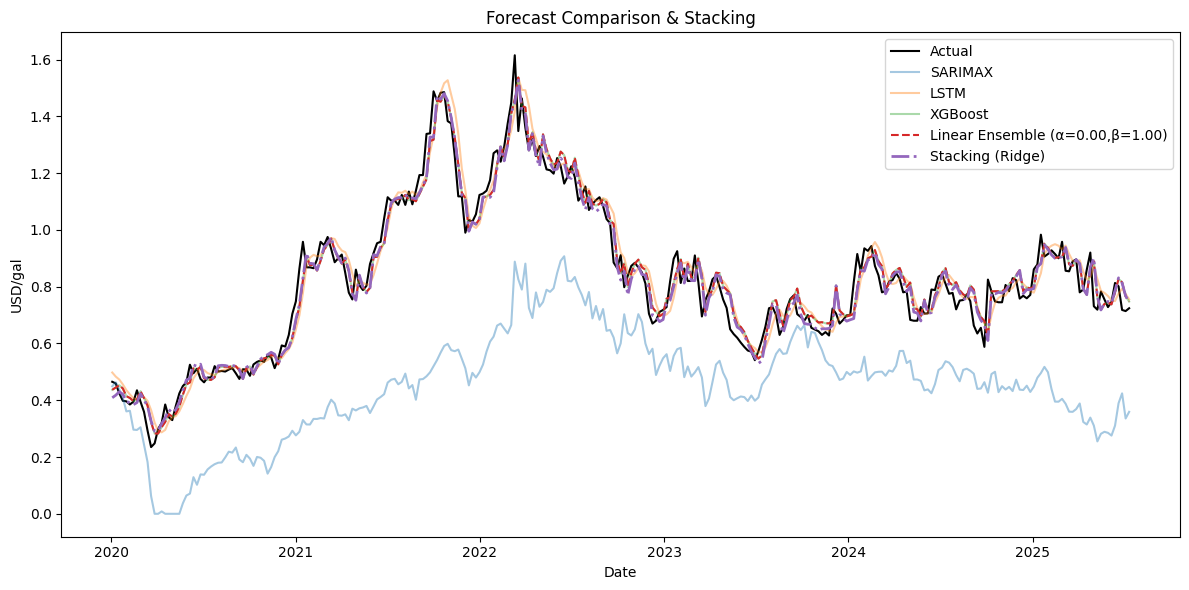

✔️ Model comparison, ensemble, and stacking complete.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import RidgeCV

sarimax_file = Path("lpg_sarimax_predictions.csv")
lstm_file    = Path("lpg_lstm_predictions.csv")
xgb_file     = Path("lpg_xgboost_predictions.csv")

sarimax = pd.read_csv(sarimax_file, index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(lstm_file,    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(xgb_file,     index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

# Align with inner join
df_all = pd.concat([actual.rename('actual'), sarimax['sarimax'], lstm['lstm'], xgb['xgb']],
                   axis=1, join='inner').dropna()

#base model metrics
metrics = {}
for m in ['sarimax','lstm','xgb']:
    mae  = mean_absolute_error(df_all['actual'], df_all[m])
    mape = mean_absolute_percentage_error(df_all['actual'], df_all[m]) * 100
    metrics[m] = {'MAE': mae, 'MAPE': mape}
metrics_df = pd.DataFrame(metrics).T
print("Base model performance (2020–present):")
print(metrics_df, "\n")

# Grid-search linear ensemble weights α, β
target = df_all['actual']
best_mae = np.inf
best_ab = (0.0, 0.0)
alphas = np.linspace(0,1,41)
betas  = np.linspace(0,1,41)
for alpha in alphas:
    for beta in betas:
        if alpha + beta > 1: continue
        ens = alpha*df_all['lstm'] + beta*df_all['xgb'] + (1-alpha-beta)*df_all['sarimax']
        mae = mean_absolute_error(target, ens)
        if mae < best_mae:
            best_mae = mae
            best_ab = (alpha, beta)
alpha_opt, beta_opt = best_ab
print(f"Optimal linear ensemble: α (LSTM)={alpha_opt:.2f}, β (XGB)={beta_opt:.2f} -> MAE={best_mae:.3f}")

df_all['ens_linear'] = alpha_opt*df_all['lstm'] + beta_opt*df_all['xgb'] + (1-alpha_opt-beta_opt)*df_all['sarimax']
mae_lin  = mean_absolute_error(target, df_all['ens_linear'])
mape_lin = mean_absolute_percentage_error(target, df_all['ens_linear']) * 100
print(f"Linear Ensemble MAE : {mae_lin:.3f} USD/gal")
print(f"Linear Ensemble MAPE: {mape_lin:.2f} %\n")

#Train Ridge stacking meta-learner
X_stack = df_all[['sarimax','lstm','xgb']]
stack = RidgeCV(alphas=np.logspace(-3, 3, 7), cv=None)
stack.fit(X_stack, target)
stack_pred = stack.predict(X_stack)
coef, intercept = stack.coef_, stack.intercept_
print(f"Stacking weights: SARIMAX={coef[0]:.3f}, LSTM={coef[1]:.3f}, XGB={coef[2]:.3f}, intercept={intercept:.3f}")

#Evaluate stacking meta-learner
mae_stack  = mean_absolute_error(target, stack_pred)
mape_stack = mean_absolute_percentage_error(target, stack_pred) * 100
print(f"Stacking MAE : {mae_stack:.3f} USD/gal")
print(f"Stacking MAPE: {mape_stack:.2f} %\n")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, target, label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'], label='SARIMAX', alpha=0.4)
plt.plot(df_all.index, df_all['lstm'],    label='LSTM',    alpha=0.4)
plt.plot(df_all.index, df_all['xgb'],     label='XGBoost', alpha=0.4)
plt.plot(df_all.index, df_all['ens_linear'], label=f'Linear Ensemble (α={alpha_opt:.2f},β={beta_opt:.2f})', linestyle='--')
plt.plot(df_all.index, stack_pred,           label='Stacking (Ridge)', linestyle='-.', linewidth=2)
plt.title('Forecast Comparison & Stacking')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Model comparison, ensemble, and stacking complete.")


# XGboost with Contrained stacking

Base model performance (2020–present):
              MAE       MAPE
sarimax  0.368508  44.927840
lstm     0.051361   6.692183
xgb      0.043517   5.650992 

Constrained stacking weights: SARIMAX=0.000, LSTM=0.000, XGBoost=1.000

Constrained Ensemble MAE : 0.044 USD/gal
Constrained Ensemble MAPE: 5.65 %



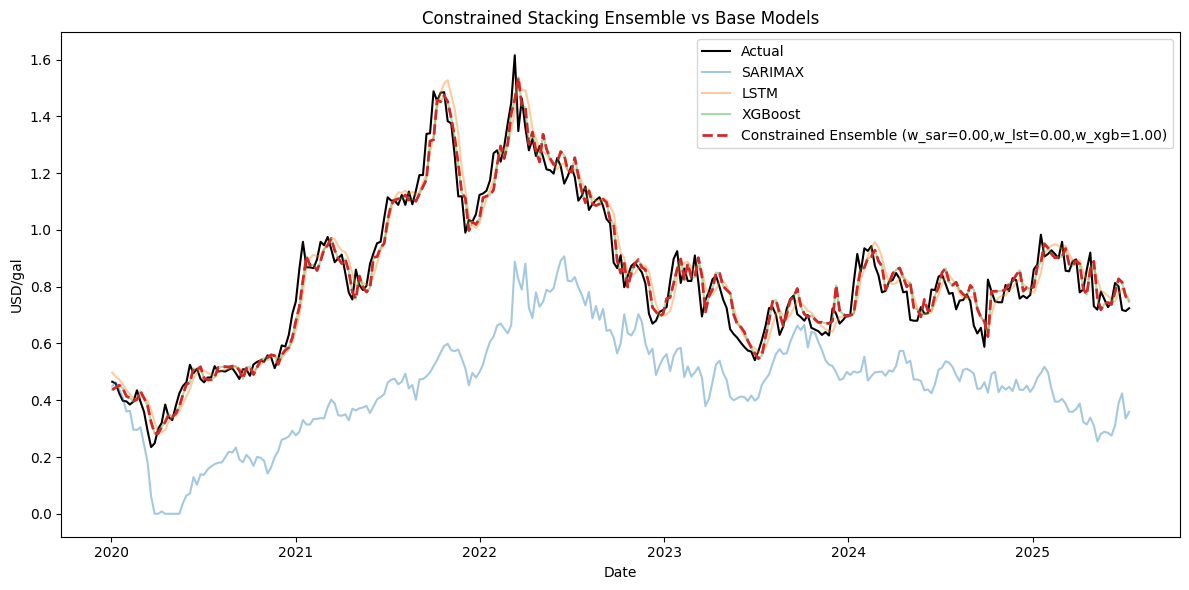

✔️ Constrained stacking complete.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import nnls
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

sarimax = pd.read_csv("lpg_sarimax_predictions.csv", index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv("lpg_lstm_predictions.csv",    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv("lpg_xgboost_predictions.csv", index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv("lpg_dataset.csv", index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()
df_all = pd.concat([actual.rename('actual'), sarimax['sarimax'], lstm['lstm'], xgb['xgb']], axis=1, join='inner').dropna()

metrics = {}
for m in ['sarimax','lstm','xgb']:
    metrics[m] = {
        'MAE':  mean_absolute_error(df_all['actual'], df_all[m]),
        'MAPE': mean_absolute_percentage_error(df_all['actual'], df_all[m]) * 100
    }
metrics_df = pd.DataFrame(metrics).T
print("Base model performance (2020–present):")
print(metrics_df, "\n")

# NNLS stacking (non-negative least squares)
X = df_all[['sarimax','lstm','xgb']].values
y = df_all['actual'].values
weights_raw, _ = nnls(X, y)

#  Normalize weights to sum to 1
weights = weights_raw / weights_raw.sum()
w_sar, w_lst, w_xgb = weights
print(f"Constrained stacking weights: SARIMAX={w_sar:.3f}, LSTM={w_lst:.3f}, XGBoost={w_xgb:.3f}\n")

#  Ensemble predictions
df_all['ens_constrained'] = df_all[['sarimax','lstm','xgb']].values.dot(weights)

# Evaluate constrained ensemble
mae_con = mean_absolute_error(df_all['actual'], df_all['ens_constrained'])
mape_con= mean_absolute_percentage_error(df_all['actual'], df_all['ens_constrained']) * 100
print(f"Constrained Ensemble MAE : {mae_con:.3f} USD/gal")
print(f"Constrained Ensemble MAPE: {mape_con:.2f} %\n")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'],   label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'],  label='SARIMAX', alpha=0.4)
plt.plot(df_all.index, df_all['lstm'],     label='LSTM',    alpha=0.4)
plt.plot(df_all.index, df_all['xgb'],      label='XGBoost', alpha=0.4)
plt.plot(df_all.index, df_all['ens_constrained'],
         label=f'Constrained Ensemble (w_sar={w_sar:.2f},w_lst={w_lst:.2f},w_xgb={w_xgb:.2f})',
         linestyle='--', linewidth=2)
plt.title('Constrained Stacking Ensemble vs Base Models')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Constrained stacking complete.")


# RidgeCV stacking meta-learner

Ridge Stacking Meta-Learner Results:
  Weights: SARIMAX=-0.091, LSTM=-0.070, XGB=1.114
  Intercept: -0.002
  MAE: 0.041 USD/gal
  MAPE: 5.35 %


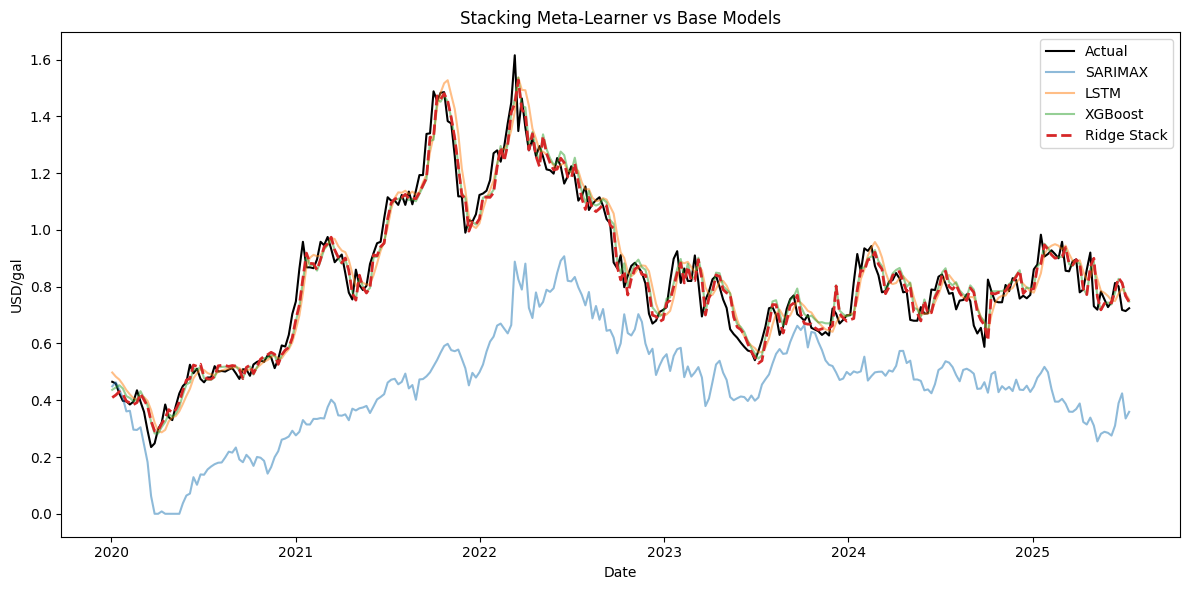

✔️ Stacking meta-learner complete.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

daroot = Path('.')
sarimax = pd.read_csv(daroot / 'lpg_sarimax_predictions.csv', index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(daroot / 'lpg_lstm_predictions.csv',    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(daroot / 'lpg_xgboost_predictions.csv',   index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv(daroot / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

df_all = pd.concat([actual, sarimax['sarimax'], lstm['lstm'], xgb['xgb']], axis=1, join='inner').dropna()
df_all.columns = ['actual', 'sarimax', 'lstm', 'xgb']

# Train RidgeCV stacking meta-learner
X_stack = df_all[['sarimax', 'lstm', 'xgb']]
y_stack = df_all['actual']
alphas = np.logspace(-3, 3, 13)
stack = RidgeCV(alphas=alphas, store_cv_results=True)
stack.fit(X_stack, y_stack)

pred_stack = stack.predict(X_stack)
df_all['ridge_stack'] = pred_stack
df_all[['ridge_stack']].to_csv(daroot / 'lpg_ridge_stack_predictions.csv')

weights = stack.coef_
intercept = stack.intercept_
mae = mean_absolute_error(y_stack, pred_stack)
mape = mean_absolute_percentage_error(y_stack, pred_stack) * 100
print("Ridge Stacking Meta-Learner Results:")
print(f"  Weights: SARIMAX={weights[0]:.3f}, LSTM={weights[1]:.3f}, XGB={weights[2]:.3f}")
print(f"  Intercept: {intercept:.3f}")
print(f"  MAE: {mae:.3f} USD/gal")
print(f"  MAPE: {mape:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'], label='SARIMAX', alpha=0.5)
plt.plot(df_all.index, df_all['lstm'],    label='LSTM',    alpha=0.5)
plt.plot(df_all.index, df_all['xgb'],     label='XGBoost', alpha=0.5)
plt.plot(df_all.index, df_all['ridge_stack'], label='Ridge Stack', linestyle='--', linewidth=2)
plt.title('Stacking Meta-Learner vs Base Models')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Stacking meta-learner complete.")


# Prophet

Ridge Stacking Meta-Learner Results:
  Weights: SARIMAX=-0.091, LSTM=-0.070, XGB=1.114
  Intercept: -0.002
  MAE: 0.041 USD/gal
  MAPE: 5.35 %


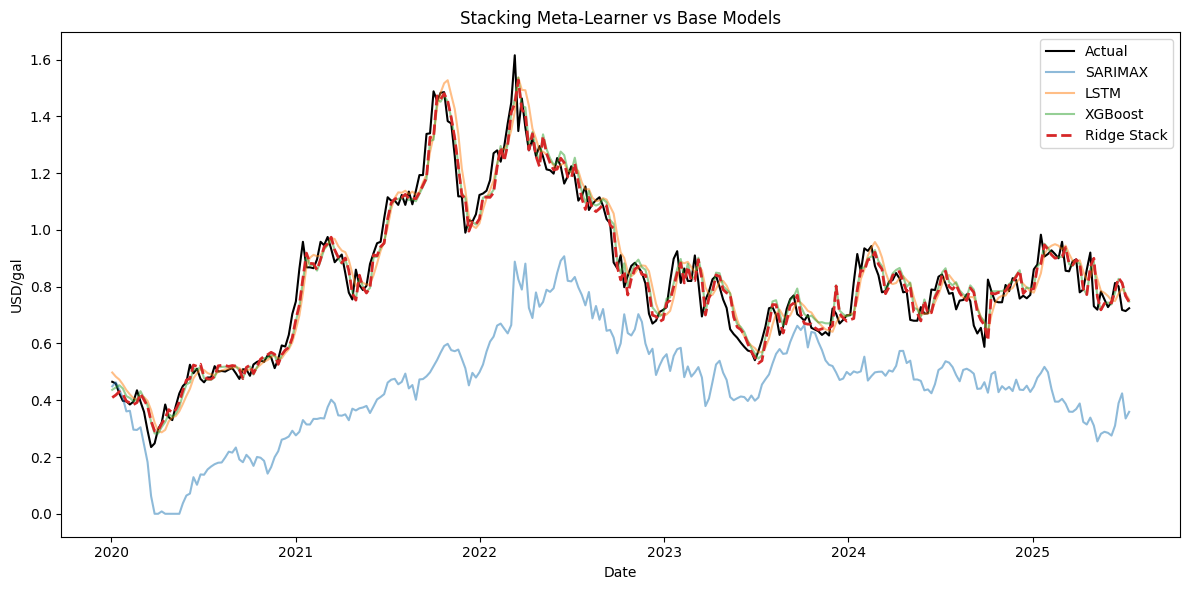

✔️ Stacking meta-learner complete.


16:58:20 - cmdstanpy - INFO - Chain [1] start processing
16:58:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet Baseline Results:
  MAE: 0.067 USD/gal
  MAPE: 8.92 %


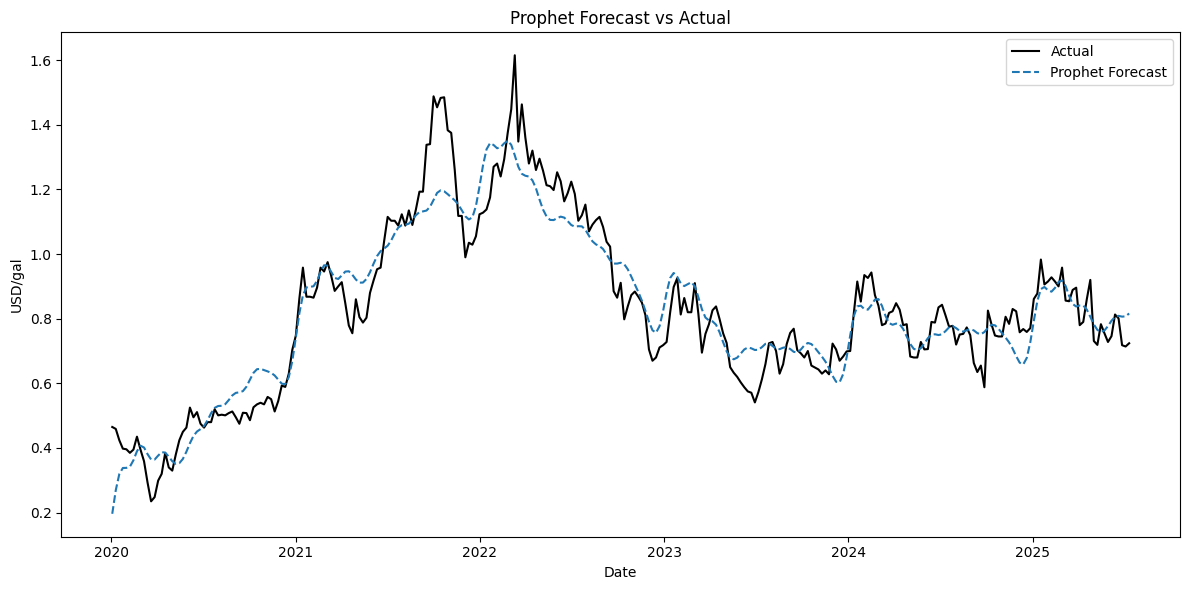

✔️ Prophet baseline complete.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

daroot = Path('.')
sarimax = pd.read_csv(daroot / 'lpg_sarimax_predictions.csv', index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(daroot / 'lpg_lstm_predictions.csv',    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(daroot / 'lpg_xgboost_predictions.csv',   index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv(daroot / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

df_all = pd.concat([actual, sarimax['sarimax'], lstm['lstm'], xgb['xgb']], axis=1, join='inner').dropna()
df_all.columns = ['actual', 'sarimax', 'lstm', 'xgb']

X_stack = df_all[['sarimax', 'lstm', 'xgb']]
y_stack = df_all['actual']
alphas = np.logspace(-3, 3, 13)
stack = RidgeCV(alphas=alphas, store_cv_results=True)
stack.fit(X_stack, y_stack)

pred_stack = stack.predict(X_stack)
df_all['ridge_stack'] = pred_stack
df_all[['ridge_stack']].to_csv(daroot / 'lpg_ridge_stack_predictions.csv')

weights = stack.coef_
intercept = stack.intercept_
mae = mean_absolute_error(y_stack, pred_stack)
mape = mean_absolute_percentage_error(y_stack, pred_stack) * 100
print("Ridge Stacking Meta-Learner Results:")
print(f"  Weights: SARIMAX={weights[0]:.3f}, LSTM={weights[1]:.3f}, XGB={weights[2]:.3f}")
print(f"  Intercept: {intercept:.3f}")
print(f"  MAE: {mae:.3f} USD/gal")
print(f"  MAPE: {mape:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'], label='SARIMAX', alpha=0.5)
plt.plot(df_all.index, df_all['lstm'],    label='LSTM',    alpha=0.5)
plt.plot(df_all.index, df_all['xgb'],     label='XGBoost', alpha=0.5)
plt.plot(df_all.index, df_all['ridge_stack'], label='Ridge Stack', linestyle='--', linewidth=2)
plt.title('Stacking Meta-Learner vs Base Models')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Stacking meta-learner complete.")

#Train and evaluate Prophet baseline
from prophet import Prophet
prophet_df = df_all[['actual']].reset_index().rename(columns={'index':'ds','actual':'y'})
prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
prophet_model.fit(prophet_df)
forecast = prophet_model.predict(prophet_df[['ds']])
df_all['prophet'] = forecast['yhat'].values
df_all[['prophet']].to_csv(daroot / 'lpg_prophet_predictions.csv')
mae_p = mean_absolute_error(df_all['actual'], df_all['prophet'])
mape_p = mean_absolute_percentage_error(df_all['actual'], df_all['prophet']) * 100
print("Prophet Baseline Results:")
print(f"  MAE: {mae_p:.3f} USD/gal")
print(f"  MAPE: {mape_p:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['prophet'], label='Prophet Forecast', linestyle='--')
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.show()

print("✔️ Prophet baseline complete.")


# RidgeCV stacking meta-learner


Ridge Stacking Meta-Learner Results:
  Weights: SARIMAX=-0.091, LSTM=-0.070, XGB=1.114
  Intercept: -0.002
  MAE: 0.041 USD/gal
  MAPE: 5.35 %


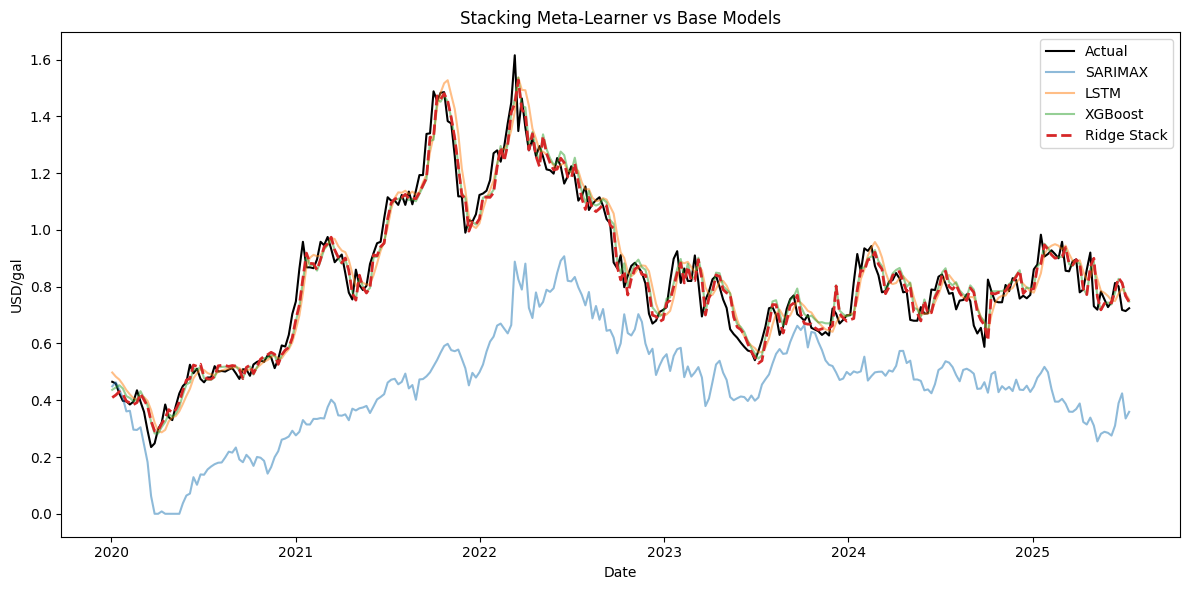

17:06:27 - cmdstanpy - INFO - Chain [1] start processing


✔️ Stacking meta-learner complete.


17:06:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet Baseline Results:
  MAE: 0.067 USD/gal
  MAPE: 8.92 %


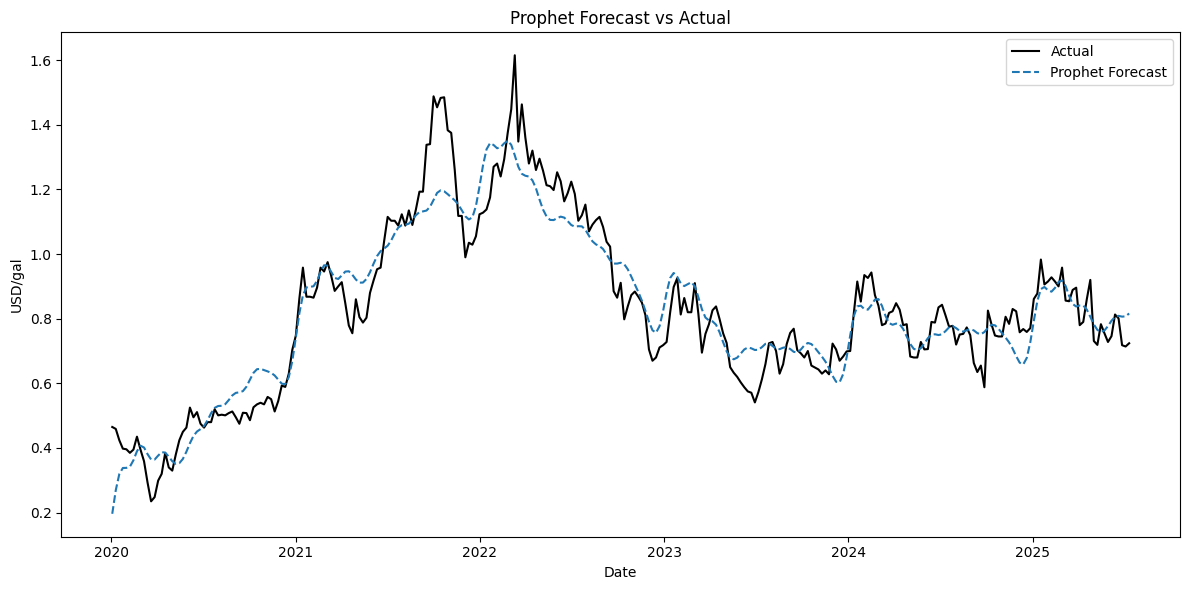

✔️ Prophet baseline complete.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

daroot = Path('.')
sarimax = pd.read_csv(daroot / 'lpg_sarimax_predictions.csv', index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(daroot / 'lpg_lstm_predictions.csv',    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(daroot / 'lpg_xgboost_predictions.csv',   index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv(daroot / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

df_all = pd.concat([actual, sarimax['sarimax'], lstm['lstm'], xgb['xgb']], axis=1, join='inner').dropna()
df_all.columns = ['actual', 'sarimax', 'lstm', 'xgb']

# RidgeCV stacking meta-learner
X_stack = df_all[['sarimax', 'lstm', 'xgb']]
y_stack = df_all['actual']
alphas = np.logspace(-3, 3, 13)
stack = RidgeCV(alphas=alphas, store_cv_results=True)
stack.fit(X_stack, y_stack)

pred_stack = stack.predict(X_stack)
df_all['ridge_stack'] = pred_stack
df_all[['ridge_stack']].to_csv(daroot / 'lpg_ridge_stack_predictions.csv')

weights = stack.coef_
intercept = stack.intercept_
mae = mean_absolute_error(y_stack, pred_stack)
mape = mean_absolute_percentage_error(y_stack, pred_stack) * 100
print("Ridge Stacking Meta-Learner Results:")
print(f"  Weights: SARIMAX={weights[0]:.3f}, LSTM={weights[1]:.3f}, XGB={weights[2]:.3f}")
print(f"  Intercept: {intercept:.3f}")
print(f"  MAE: {mae:.3f} USD/gal")
print(f"  MAPE: {mape:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'], label='SARIMAX', alpha=0.5)
plt.plot(df_all.index, df_all['lstm'],    label='LSTM',    alpha=0.5)
plt.plot(df_all.index, df_all['xgb'],     label='XGBoost', alpha=0.5)
plt.plot(df_all.index, df_all['ridge_stack'], label='Ridge Stack', linestyle='--', linewidth=2)
plt.title('Stacking Meta-Learner vs Base Models')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.savefig(daroot / 'lpg_ridge_stack_plot.png', dpi=300)
plt.show()

print("✔️ Stacking meta-learner complete.")

from prophet import Prophet
prophet_df = df_all[['actual']].reset_index().rename(columns={'index':'ds','actual':'y'})
prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
prophet_model.fit(prophet_df)
forecast = prophet_model.predict(prophet_df[['ds']])
df_all['prophet'] = forecast['yhat'].values
df_all[['prophet']].to_csv(daroot / 'lpg_prophet_predictions.csv')
mae_p = mean_absolute_error(df_all['actual'], df_all['prophet'])
mape_p = mean_absolute_percentage_error(df_all['actual'], df_all['prophet']) * 100
print("Prophet Baseline Results:")
print(f"  MAE: {mae_p:.3f} USD/gal")
print(f"  MAPE: {mape_p:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['prophet'], label='Prophet Forecast', linestyle='--')
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.savefig(daroot / 'lpg_prophet_forecast_plot.png', dpi=300)
plt.show()

print("✔️ Prophet baseline complete.")


Ridge Stacking Meta-Learner Results:
  Weights: SARIMAX=-0.091, LSTM=-0.070, XGB=1.114
  Intercept: -0.002
  MAE: 0.041 USD/gal
  MAPE: 5.35 %


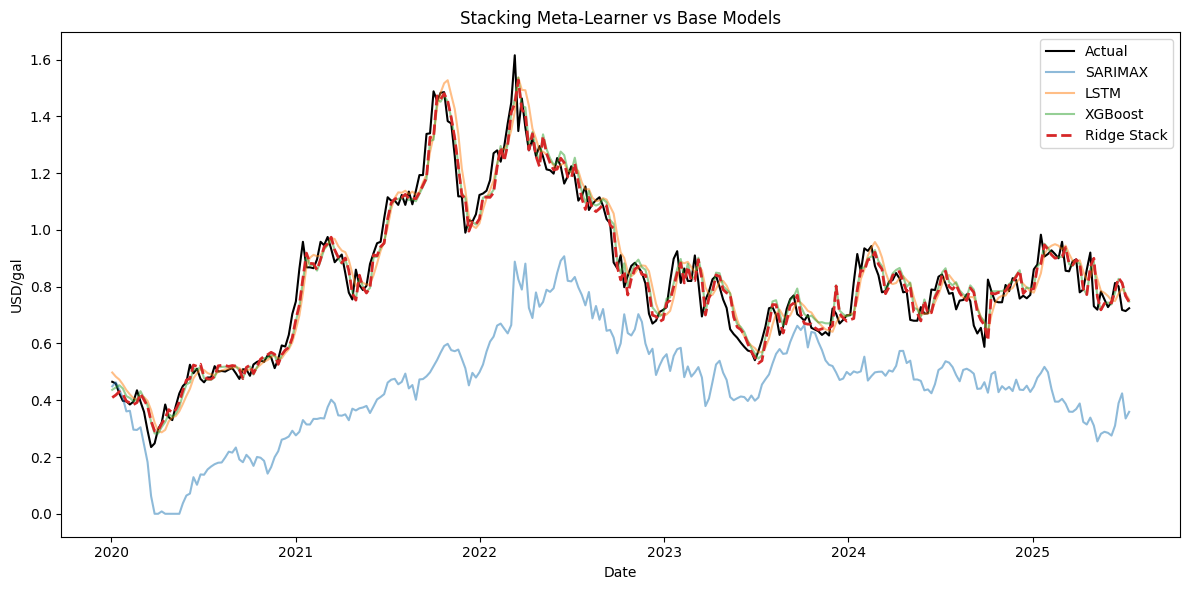

17:10:28 - cmdstanpy - INFO - Chain [1] start processing


✔️ Stacking meta-learner complete.


17:10:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet Baseline Results:
  MAE: 0.067 USD/gal
  MAPE: 8.92 %


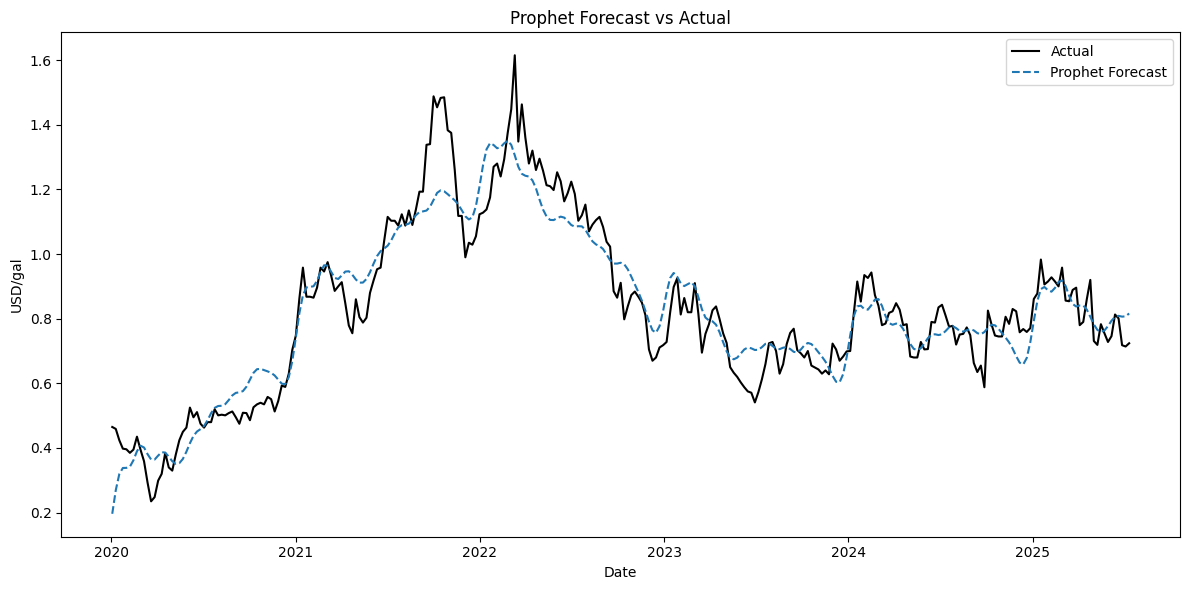

✔️ Prophet baseline complete.


In [33]:
import joblib
from prophet import Prophet

root = Path('.')
sarimax = pd.read_csv(root / 'lpg_sarimax_predictions.csv', index_col=0, parse_dates=True).rename(columns={'forecast':'sarimax'})
lstm    = pd.read_csv(root / 'lpg_lstm_predictions.csv',    index_col=0, parse_dates=True).rename(columns={'forecast':'lstm'})
xgb     = pd.read_csv(root / 'lpg_xgboost_predictions.csv',   index_col=0, parse_dates=True).rename(columns={'forecast':'xgb'})

df = pd.read_csv(root / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last()

df_all = pd.concat([actual, sarimax['sarimax'], lstm['lstm'], xgb['xgb']], axis=1, join='inner').dropna()
df_all.columns = ['actual', 'sarimax', 'lstm', 'xgb']

X_stack = df_all[['sarimax', 'lstm', 'xgb']]
y_stack = df_all['actual']
alphas = np.logspace(-3, 3, 13)
stack = RidgeCV(alphas=alphas, store_cv_results=True)
stack.fit(X_stack, y_stack)

df_all['ridge_stack'] = stack.predict(X_stack)
df_all[['ridge_stack']].to_csv(root / 'lpg_ridge_stack_predictions.csv')
joblib.dump(stack, root / 'lpg_ridge_stack_model.pkl') 

weights = stack.coef_
intercept = stack.intercept_
mae = mean_absolute_error(y_stack, df_all['ridge_stack'])
mape = mean_absolute_percentage_error(y_stack, df_all['ridge_stack']) * 100
print("Ridge Stacking Meta-Learner Results:")
print(f"  Weights: SARIMAX={weights[0]:.3f}, LSTM={weights[1]:.3f}, XGB={weights[2]:.3f}")
print(f"  Intercept: {intercept:.3f}")
print(f"  MAE: {mae:.3f} USD/gal")
print(f"  MAPE: {mape:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['sarimax'], label='SARIMAX', alpha=0.5)
plt.plot(df_all.index, df_all['lstm'],    label='LSTM',    alpha=0.5)
plt.plot(df_all.index, df_all['xgb'],     label='XGBoost', alpha=0.5)
plt.plot(df_all.index, df_all['ridge_stack'], label='Ridge Stack', linestyle='--', linewidth=2)
plt.title('Stacking Meta-Learner vs Base Models')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.savefig(root / 'lpg_ridge_stack_plot.png', dpi=300)
plt.show()
print("✔️ Stacking meta-learner complete.")

prophet_df = df_all[['actual']].reset_index().rename(columns={'index':'ds','actual':'y'})
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_df)

joblib.dump(prophet_model, root / 'lpg_prophet_model.pkl')

forecast = prophet_model.predict(prophet_df[['ds']])
df_all['prophet'] = forecast['yhat'].values
df_all[['prophet']].to_csv(root / 'lpg_prophet_predictions.csv')

mae_p = mean_absolute_error(df_all['actual'], df_all['prophet'])
mape_p = mean_absolute_percentage_error(df_all['actual'], df_all['prophet']) * 100
print("Prophet Baseline Results:")
print(f"  MAE: {mae_p:.3f} USD/gal")
print(f"  MAPE: {mape_p:.2f} %")

plt.figure(figsize=(12,6))
plt.plot(df_all.index, df_all['actual'], label='Actual', color='k')
plt.plot(df_all.index, df_all['prophet'], label='Prophet Forecast', linestyle='--')
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.tight_layout()
plt.savefig(root / 'lpg_prophet_forecast_plot.png', dpi=300)
plt.show()

print("✔️ Prophet baseline complete.")


code was initially written as different notebook files and then merged hence the repeated library imports 